<h1>Проект: линейные модели в машинном обучении<span class="tocSkip"></span></h1>

**Введение**

<div style="background-color:lavender; color:#black; text-align:left; padding:2%">
    
    
**Описание и цель проекта:**
    
В IT-компанию поступил запрос от владельца молочного хозяйства "Вольный луг". Для расширения поголовья стада коров фермер заключил контракт на покупку коров с ассоциацией пастбищ "ЭкоФерма". При этом условия конракта позволяют фермеру отобрать каров согласно его критериям: буренка должна давать не менее 6000 кг молока в год, а ее надой должен быть вкусным.
 
Необходимо две прогнозные модели для отбора буренок в поголовье: одна должна прогнозировать возможный удой, вторая - расчитывать вероятность получения вкусного молока.

**В ходе реализации проекта будут выполнены следующие задачи:**

**1. [Первичный анализ общей информации о данных](#info)**

**2. [Предварительная обработка данных:](#prepare)**
- проверить наличие пропусков и обработать их;
- проверить наличие дубликатов и обработать их;
- изучить и, при необходимости, изменить типы данных;
- проверить наличие аномалий в данных.

**3. [Исследовательский анализ данных:](#analysis)**
- провести статистический анализ всех признаков;
- визулизировать с помощью графиков данные по каждому признаку;
- определить, есть ли аномальные значения в данных: выбросы, необычное распределение количественных признаков и прочее;
- при необходимости описать процесс обработки выявленных аномалий в данных.

**4. [Проведение корреляционного анализа признаков в датасете `ferma_main.csv`:](#corr)**
- изучить взаимосвязь между признаками: расчет коэффициентов корреляции;
- построить диаграмму рассеяния для признака `удой` и всех количественных признаков с учетом значения категориальных признаков;
- сделать выводы оо взаимосвязи признаков.

**5. [Задача регрессии:](#regress)**
- подготовить данные датасета `ferma_main.csv` и обучить на них первую модель линейной регрессии;
- подготовить данные с учетом связи входных признаков с целевым и обучить на них вторую модель линейной регрессии;
- добавить в данные новый признак и обучить на них третью модель линейной регрессии;
- сравнить качество полученных моделей, сопоставив их R^2 и остатки;
- оценить качество каждой модели по трем метрикам: MSE, MAE, RMSE;
- с помощью наилучшей по метрикам модели спрогнозировать удой коров, которых фермер хочет купить (данные в датасете `cow_buy.csv`).

**6. [Задача классификации](#class)**
- подготовить данные датасета `ferma_main.csv` и обучить на них модель логистической регрессии;
- проанализировать модель логистической регрессии и сделать выводы;
- с помощью обученной модели спрогнозировать вкус молока коров, которых фермер хочет купить (данные в датасете `cow_buy.csv`).

**7. [Выводы исследования](#concl)**

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Общая-информация-о-данных" data-toc-modified-id="Общая-информация-о-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Общая информация о данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Проверка-и-обработка-пропусков-в-данных" data-toc-modified-id="Проверка-и-обработка-пропусков-в-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Проверка и обработка пропусков в данных</a></span></li><li><span><a href="#Проверка-и-обработка-дубликатов" data-toc-modified-id="Проверка-и-обработка-дубликатов-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Проверка и обработка дубликатов</a></span></li><li><span><a href="#Типы-данных" data-toc-modified-id="Типы-данных-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Типы данных</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Статичстический-анализ-признаков-в-датафрейме-df_main" data-toc-modified-id="Статичстический-анализ-признаков-в-датафрейме-df_main-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Статичстический анализ признаков в датафрейме df_main</a></span></li><li><span><a href="#Статичстический-анализ-признаков-в-датафрейме-df_dad" data-toc-modified-id="Статичстический-анализ-признаков-в-датафрейме-df_dad-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Статичстический анализ признаков в датафрейме df_dad</a></span></li><li><span><a href="#Статичстический-анализ-признаков-в-датафрейме-df_buy" data-toc-modified-id="Статичстический-анализ-признаков-в-датафрейме-df_buy-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Статичстический анализ признаков в датафрейме df_buy</a></span></li></ul></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Корреляционный анализ</a></span><ul class="toc-item"><li><span><a href="#Взаимосвязь-между-признаками-в-датафрейме-df_main" data-toc-modified-id="Взаимосвязь-между-признаками-в-датафрейме-df_main-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Взаимосвязь между признаками в датафрейме df_main</a></span></li><li><span><a href="#Диаграммы-рассеяния" data-toc-modified-id="Диаграммы-рассеяния-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Диаграммы рассеяния</a></span><ul class="toc-item"><li><span><a href="#1.-Удой-(milk_yield_kg)-и-ЭКЕ-(energy_feed_unit)" data-toc-modified-id="1.-Удой-(milk_yield_kg)-и-ЭКЕ-(energy_feed_unit)-4.2.1"><span class="toc-item-num">4.2.1&nbsp;&nbsp;</span><em>1. Удой (milk_yield_kg) и ЭКЕ (energy_feed_unit)</em></a></span></li><li><span><a href="#2.-Удой-и-значение-сырого-протеина-в-корме" data-toc-modified-id="2.-Удой-и-значение-сырого-протеина-в-корме-4.2.2"><span class="toc-item-num">4.2.2&nbsp;&nbsp;</span><em>2. Удой и значение сырого протеина в корме</em></a></span></li><li><span><a href="#3.-Удой-и-соотношение-сахара-к-протеину-в-корме-коровы" data-toc-modified-id="3.-Удой-и-соотношение-сахара-к-протеину-в-корме-коровы-4.2.3"><span class="toc-item-num">4.2.3&nbsp;&nbsp;</span><em>3. Удой и соотношение сахара к протеину в корме коровы</em></a></span></li><li><span><a href="#4.-Удой-и-процент-жирности" data-toc-modified-id="4.-Удой-и-процент-жирности-4.2.4"><span class="toc-item-num">4.2.4&nbsp;&nbsp;</span><em>4. Удой и процент жирности</em></a></span></li><li><span><a href="#5.-Удой-и-процент-протеина-в-молоке" data-toc-modified-id="5.-Удой-и-процент-протеина-в-молоке-4.2.5"><span class="toc-item-num">4.2.5&nbsp;&nbsp;</span><em>5. Удой и процент протеина в молоке</em></a></span></li></ul></li></ul></li><li><span><a href="#Обучение-модели-линейной-регрессии" data-toc-modified-id="Обучение-модели-линейной-регрессии-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Обучение модели линейной регрессии</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных-и-обучение-первой-модели-линейной-регрессии" data-toc-modified-id="Подготовка-данных-и-обучение-первой-модели-линейной-регрессии-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Подготовка данных и обучение первой модели линейной регрессии</a></span></li><li><span><a href="#Дополнительная-обработка-данных-и-подготовка-второй-модели-регрессии" data-toc-modified-id="Дополнительная-обработка-данных-и-подготовка-второй-модели-регрессии-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Дополнительная обработка данных и подготовка второй модели регрессии</a></span></li><li><span><a href="#Построение-третьей-модели" data-toc-modified-id="Построение-третьей-модели-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Построение третьей модели</a></span></li><li><span><a href="#Оценка-качества-моделей-по-метрикам-MSE,-MAE,-RMSE" data-toc-modified-id="Оценка-качества-моделей-по-метрикам-MSE,-MAE,-RMSE-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Оценка качества моделей по метрикам MSE, MAE, RMSE</a></span><ul class="toc-item"><li><span><a href="#MSE" data-toc-modified-id="MSE-5.4.1"><span class="toc-item-num">5.4.1&nbsp;&nbsp;</span>MSE</a></span></li><li><span><a href="#MAE" data-toc-modified-id="MAE-5.4.2"><span class="toc-item-num">5.4.2&nbsp;&nbsp;</span>MAE</a></span></li><li><span><a href="#RMSE" data-toc-modified-id="RMSE-5.4.3"><span class="toc-item-num">5.4.3&nbsp;&nbsp;</span>RMSE</a></span></li></ul></li><li><span><a href="#Прогноз-с-помощью-модели" data-toc-modified-id="Прогноз-с-помощью-модели-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Прогноз с помощью модели</a></span></li></ul></li><li><span><a href="#Обучение-модели-логистической-регрессии" data-toc-modified-id="Обучение-модели-логистической-регрессии-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Обучение модели логистической регрессии</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных,-обучение-и-оценка-с-помощью-метрик-модели-логистической-регрессии" data-toc-modified-id="Подготовка-данных,-обучение-и-оценка-с-помощью-метрик-модели-логистической-регрессии-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Подготовка данных, обучение и оценка с помощью метрик модели логистической регрессии</a></span></li><li><span><a href="#Метрики-accuracy,-precision,-recall" data-toc-modified-id="Метрики-accuracy,-precision,-recall-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Метрики accuracy, precision, recall</a></span></li><li><span><a href="#Предсказание-модели" data-toc-modified-id="Предсказание-модели-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Предсказание модели</a></span></li></ul></li><li><span><a href="#Итоговые-выводы" data-toc-modified-id="Итоговые-выводы-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Итоговые выводы</a></span></li></ul></div>

**Описание данных**

**Файл `ferma_main.csv`**

1. `id` — уникальный идентификатор коровы


2. `Удой, кг` — масса молока, которую корова дает в год (в килограммах)


3. `ЭКЕ` — показатель питательности корма коровы


4. `Сырой протеин, г` — содержание сырого протеина в корме (в граммах)


5. `СПО` — отношение сахара к протеину в корме коровы


6. `Порода` — порода коровы


7. `Тип пастбища` — ландшафт лугов, на которых паслась корова.


8. `порода папы_быка` — порода папы коровы


9. `Жирность, %` — содержание жиров в молоке (в процентах)


10. `Белок, %` — содержание белков в молоке (в процентах)


11. `Вкус молока` — оценка вкуса по личным критериям фермера, бинарный признак (вкусно/не вкусно)

12. `Возраст` — возраст коровы, бинарный признак (менее_2_лет/более_2_лет)


**Файл `ferma_dad.csv`**

1. `id` — уникальный идентификатор коровы


2. `Имя Папы` — имя папы коровы


**Файл `cow_buy.csv`**

1. `Порода` — порода коровы


2. `Тип пастбища` — ландшафт лугов, на которых паслась корова


3. `порода папы_быка` — порода папы коровы


4. `Имя_папы` — имя папы коровы


5. `Текущая_жирность,%` - содержание жиров в молоке (в процентах)


6. `Текущий_уровень_белок,%` - содержание белков в молоке (в процентах)


7. `Возраст` - возраст коровы, бинарный признак (менее_2_лет/более_2_лет)

## Общая информация о данных 
<a id="info"></a>

In [1]:
# Установка 
!pip install phik -q
import phik

# Импорт библиотек, которые понадобятся для исследования и обработки данных
# общие
import pandas as pd
import numpy as np
from scipy import stats as st
import math as m
from math import sqrt

# для визуализации
import matplotlib.pyplot as plt 
import seaborn as sns

# для обработки данных перед обучением модели
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# модели линейной и логистической регрессии
from sklearn.linear_model import LinearRegression, LogisticRegression

# метрики для оценки моделей линейной регрессии
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# метрики для оценки моделей логистической регрессии
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

In [2]:
# загрузим файл ferma_main.csv
try:
    df_main = pd.read_csv('/datasets/ferma_main.csv', sep=';')
except:
    df_main = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv', sep=';')

In [3]:
# загрузим файл ferma_dad.csv
try:
    df_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
except:
    df_dad = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv', sep=';')

In [4]:
# загрузим файл cow_buy.csv
try:
    df_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';')
except:
    df_buy = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv', sep=';')

In [5]:
# посмотрим на данные из ferma_main.csv
df_main.head(10)

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет
5,6,5254,"12,7",1806,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,13","3,078",вкусно,менее_2_лет
6,7,5910,"13,2",1792,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,48","3,077",вкусно,более_2_лет
7,8,6179,"14,7",1806,"0,93",Вис Бик Айдиал,Равнинные,Айдиал,"3,55","3,076",вкусно,более_2_лет
8,9,6783,"14,2",1918,"0,94",РефлешнСоверинг,Холмистое,Айдиал,"3,71","3,077",вкусно,более_2_лет
9,10,5339,"13,4",1791,"0,895",Вис Бик Айдиал,Холмистое,Соверин,"3,13","3,075",вкусно,менее_2_лет


In [6]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            


Названия столбцов необходимо изменить в соответствии с стилистическими правилами.

In [7]:
df_main.columns = ['id', 'milk_yield_kg', 'energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio',\
                  'breed', 'pasture_type', 'fathers_breed', 'fat_%', 'protein_%', 'milk_taste', 'age']
df_main.columns

Index(['id', 'milk_yield_kg', 'energy_feed_unit', 'crude_protein_g',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'fathers_breed',
       'fat_%', 'protein_%', 'milk_taste', 'age'],
      dtype='object')

In [8]:
# посмотрим на данные из ferma_dad.csv
df_dad.head(10)

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин
5,6,Барин
6,7,Соловчик
7,8,Геркулес
8,9,Буйный
9,10,Барин


In [9]:
df_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


 
Названия столбцов необходимо изменить в соответствии с стилистическими правилами.

In [10]:
df_dad.columns = ['id', 'fathers_name']
df_dad.columns

Index(['id', 'fathers_name'], dtype='object')

In [11]:
# посмотрим на данные из cow_buy.csv
df_buy.head(10)

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,"3,63","3,053",менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,57","3,079",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,079",менее_2_лет


In [12]:
df_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


 
Названия столбцов необходимо изменить в соответствии с стилистическими правилами.

In [13]:
df_buy.columns = ['breed', 'pasture_type', 'fathers_breed', 'fathers_name', 'fat_%', 'protein_%', 'age']
df_buy.columns

Index(['breed', 'pasture_type', 'fathers_breed', 'fathers_name', 'fat_%',
       'protein_%', 'age'],
      dtype='object')

Изучим данные на наличие пропусков.

Также, необходимо будет привести к общепринятому стилю названия столбцов и подробнее изучить типы данных в каждом столбце.

##  Предобработка данных 
<a id="prepare"></a>

### Проверка и обработка пропусков в данных

Проверим наличие пропусков в каждом из датасетов.

In [14]:
print('Количество пропусков в датасете ferma_main.csv')
df_main.isna().sum()

Количество пропусков в датасете ferma_main.csv


id                     0
milk_yield_kg          0
energy_feed_unit       0
crude_protein_g        0
sugar_protein_ratio    0
breed                  0
pasture_type           0
fathers_breed          0
fat_%                  0
protein_%              0
milk_taste             0
age                    0
dtype: int64

In [15]:
print('Количество пропусков в датасете `ferma_dad.csv`')
df_dad.isna().sum()

Количество пропусков в датасете `ferma_dad.csv`


id              0
fathers_name    0
dtype: int64

In [16]:
print('Количество пропусков в датасете `cow_buy.csv`')
df_buy.isna().sum()

Количество пропусков в датасете `cow_buy.csv`


breed            0
pasture_type     0
fathers_breed    0
fathers_name     0
fat_%            0
protein_%        0
age              0
dtype: int64

Пропусков в данных не обнаружено. Можно приступать к обработке дубликатов.

### Проверка и обработка дубликатов

Проверим датафреймы на наличие явных дубликатов и обработаем их при необходимости.

In [17]:
df_main[df_main.duplicated()]

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,fathers_breed,fat_%,protein_%,milk_taste,age
629,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
630,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
631,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
632,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
633,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет


В датафрейме `df_main` есть явные дубликаты, их необходимо удалить.

In [18]:
# удаляем дубликаты
df_main = df_main.drop_duplicates()

In [19]:
# проверка обработки дубликатов
df_main.duplicated().sum()

0

In [20]:
df_dad[df_dad.duplicated()]

,id,fathers_name


В датафрейме `df_dad` явные дубликаты отсутствуют.

In [21]:
df_buy[df_buy.duplicated()]

,breed,pasture_type,fathers_breed,fathers_name,fat_%,protein_%,age
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
14,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
19,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


В датафрейме `df_buy` есть явные дубликаты, но все-таки это могут быть разные коровы. Поэтому пока оставим эти строки без изменений.

Явные дубликаты в данных обработаны, теперь проверим данные на наличие неявных дубликатов.

In [22]:
df_main.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,fathers_breed,fat_%,protein_%,milk_taste,age
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


Неявные дубликаты могут возникнуть в столбцах `breed`, `pasture_type`, `fathers_breed`, `milk_taste`, `age`. Проверим каждый из них.

In [23]:
df_main['breed'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [24]:
df_main['pasture_type'].unique()

array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

В столбце с типом пастбища есть тип "Равнинное" и "Равнинные", что по сути является одним и тем же типом. Обработаем эти значения.

In [25]:
df_main.loc[df_main['pasture_type']=='Равнинные','pasture_type'] = 'Равнинное'

Для удобства также преобразуем данные в столбце с типом пастбищ так, чтобы все буквы были строчными.


In [26]:
df_main['pasture_type'] = df_main['pasture_type'].str.lower()

In [27]:
# проверка уникальных значений в столбце с типом пастбищ после обработки
df_main['pasture_type'].unique()

array(['равнинное', 'холмистое'], dtype=object)

In [28]:
df_main['fathers_breed'].unique()

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

В столбце с породой папы коровы неявными дубликатами являются "Айдиал" и "Айдиалл". Обработаем эти значения.

In [29]:
df_main.loc[df_main['fathers_breed']=='Айдиалл','fathers_breed'] = 'Айдиал'

In [30]:
# проверка уникальных значений в столбце с породой папы коровы после обработки
df_main['fathers_breed'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

In [31]:
df_main['milk_taste'].unique()

array(['вкусно', 'не вкусно'], dtype=object)

In [32]:
df_main['age'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

Таким образом, в датафрейме `df_main` были выявлены и обработаны неявные дубликаты в столбцах `pasture_type`, `fathers_breed`.

Посмотрим на данные в датафрейме `df_dad`.

In [33]:
df_dad.head()

,id,fathers_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


Неявные дубликаты могут быть в столбце `fathers_name`, проверим их наличие.

In [34]:
df_dad['fathers_name'].unique()

array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

Неявных дубликатов в датафрейме `df_dad` не найдено.


Посмотрим на данные в `df_buy`.

In [35]:
df_buy.head()

,breed,pasture_type,fathers_breed,fathers_name,fat_%,protein_%,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


Проверим столбцы `breed`, `pasture_type`, `fathers_breed`, `fathers_name`, `age`.

In [36]:
df_buy['breed'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [37]:
df_buy['pasture_type'].unique()

array(['холмистое', 'равнинное'], dtype=object)

In [38]:
df_buy['fathers_breed'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

In [39]:
df_buy['fathers_name'].unique()

array(['Геркулес', 'Буйный', 'Барин', 'Соловчик'], dtype=object)

In [40]:
df_buy['age'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

Таким образом, неявных дубликатов в датафрейме `df_buy` не обнаружено.

### Типы данных

In [41]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   629 non-null    int64 
 1   milk_yield_kg        629 non-null    int64 
 2   energy_feed_unit     629 non-null    object
 3   crude_protein_g      629 non-null    int64 
 4   sugar_protein_ratio  629 non-null    object
 5   breed                629 non-null    object
 6   pasture_type         629 non-null    object
 7   fathers_breed        629 non-null    object
 8   fat_%                629 non-null    object
 9   protein_%            629 non-null    object
 10  milk_taste           629 non-null    object
 11  age                  629 non-null    object
dtypes: int64(3), object(9)
memory usage: 63.9+ KB


Для осуществления расчетов с количественными данными необходимо изменить их тип на `float` в столбцах `energy_feed_unit`, `sugar_protein_ratio`, `fat_%`, `protein_%`.

Напишем функцию для обработки, которая:
- изменит все символы `,` на `.` в числах
- преобразует в тип данных `float`

In [42]:
def change_func(data, column):
    for i in range(0, len(data[column])):
        data.loc[i, column] = data.loc[i, column].replace(',','.')
    data[column] = data[column].astype('float')

In [43]:
list_to_change = ['energy_feed_unit', 'sugar_protein_ratio', 'fat_%', 'protein_%']
for x in list_to_change:
    change_func(df_main, x)

In [44]:
# проверка типов данных после обработки
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   629 non-null    int64  
 1   milk_yield_kg        629 non-null    int64  
 2   energy_feed_unit     629 non-null    float64
 3   crude_protein_g      629 non-null    int64  
 4   sugar_protein_ratio  629 non-null    float64
 5   breed                629 non-null    object 
 6   pasture_type         629 non-null    object 
 7   fathers_breed        629 non-null    object 
 8   fat_%                629 non-null    float64
 9   protein_%            629 non-null    float64
 10  milk_taste           629 non-null    object 
 11  age                  629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 80.0+ KB


Тип данных в нужных столбцах преобразован, можно перейти к обработке датафрейма `df_dad`.

In [45]:
df_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            629 non-null    int64 
 1   fathers_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


В данном датафрейме не нужно менять тип данных. Перейдем к датафрейму `df_buy`.

In [46]:
df_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   breed          20 non-null     object
 1   pasture_type   20 non-null     object
 2   fathers_breed  20 non-null     object
 3   fathers_name   20 non-null     object
 4   fat_%          20 non-null     object
 5   protein_%      20 non-null     object
 6   age            20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


В датафрейме `df_buy` нужно преобразовать тип данных в столбцах `fat_%`, `protein_%` и сделать его `float`.

Для этого воспользуемся функцией написанной ранее.

In [47]:
list_to_change = ['fat_%', 'protein_%']
for i in list_to_change:
    change_func(df_buy, i)

In [48]:
# проверка типов данных после обработки
df_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   breed          20 non-null     object 
 1   pasture_type   20 non-null     object 
 2   fathers_breed  20 non-null     object 
 3   fathers_name   20 non-null     object 
 4   fat_%          20 non-null     float64
 5   protein_%      20 non-null     float64
 6   age            20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


Итак, мы изменили типы данных везде, где это было необходимо. 

**Выводы:**
- Каждый из датафреймов был проверен на наличие пропусков. Пропуски в данных обнаружены не были.
- Были выявлены и обработаны явные дубликаты в датафреймах `df_main`, `df_buy`. Повторяющиеся значения были удалены.
- Были выявлены и устранены неявные дубликаты в столбцах **pasture_type**, **fathers_breed** в датафрейме `df_main`.
- В датафрейме `df_main` изменен тип данных в столбцах `energy_feed_unit`, `sugar_protein_ratio`, `fat_%`, `protein_%` на тип **float**.
- В датафрейме `df_buy` изменен тип данных в столбцах `fat_%`, `protein_%` на тип **float**.

## Исследовательский анализ данных  
<a id="analysis"></a>

### Статичстический анализ признаков в датафрейме df_main

Проанализируем каждый из признаков датафрейма df_main и посмотрим, как распределяются значения, есть ли в данных аномалии и как их можно обработать.

*1. Удой (milk_yield_kg)*

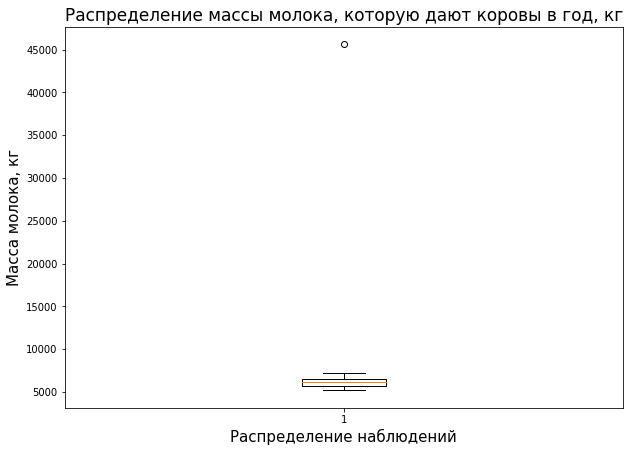

In [49]:
plt.figure(figsize=(10, 7))
plt.boxplot(df_main['milk_yield_kg'])
plt.xlabel('Распределение наблюдений', size=15)
plt.ylabel('Масса молока, кг', size=15)
plt.title('Распределение массы молока, которую дают коровы в год, кг', size=17)
plt.show()

In [50]:
df_main['milk_yield_kg'].describe()

count      629.000000
mean      6188.750397
std       1644.795489
min       5204.000000
25%       5751.000000
50%       6133.000000
75%       6501.000000
max      45616.000000
Name: milk_yield_kg, dtype: float64

На диаграмме "ящика" видно, что в данных с массой молока, которую дают коровы в год, есть аномально большое значение. Посмотрим на него.

In [51]:
df_main[df_main['milk_yield_kg']==max(df_main['milk_yield_kg'])]

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,fathers_breed,fat_%,protein_%,milk_taste,age
16,17,45616,11.5,1675,0.93,Вис Бик Айдиал,холмистое,Айдиал,3.22,3.076,вкусно,более_2_лет


Такое аномально высокое значение будет смещать оценку удоя. Возможно, при формировании данных произошла ошибка и было внесено некорректное значение. Конечно, может быть такое, что корова с id 17 являлась настолько выдающейся и уникальной, что удой, по сравнению с остальными, действительно оказался больше в 10 раз. Однако такой выброс будет мешать при дальнейшем построении и обучении модели, поэтому его лучше исключить из данных.

In [52]:
df_main = df_main[df_main['milk_yield_kg']!=max(df_main['milk_yield_kg'])].reset_index(drop=True)

Теперь построим гистограмму, чтобы посмотреть распределение данных после исключения выброса.

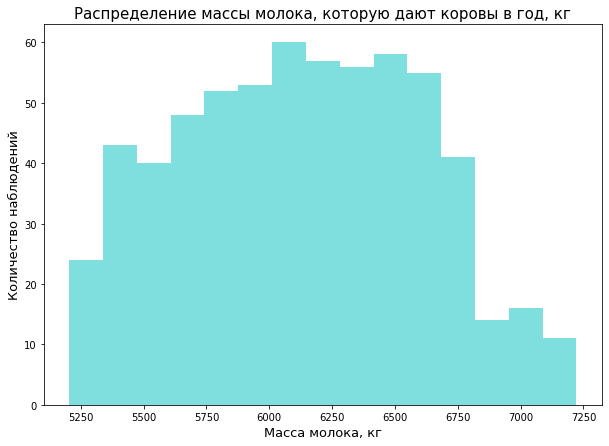

In [53]:
plt.figure(figsize=(10,7))
plt.hist(df_main['milk_yield_kg'], bins=15, color='c', alpha=0.5)
plt.xlabel('Масса молока, кг', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение массы молока, которую дают коровы в год, кг', size=15)
plt.show()

In [54]:
df_main['milk_yield_kg'].describe()

count     628.000000
mean     6125.968153
std       475.857053
min      5204.000000
25%      5749.750000
50%      6132.500000
75%      6501.000000
max      7222.000000
Name: milk_yield_kg, dtype: float64

Теперь в данных нет аномальных значений, стандартное отклонение значительно уменьшилось. Значения удоя у коров распределены в диапазоне от 5204 кг/год до 7222 кг/год. Так как большой выделяющийся пик один, распределение в целомможно назвать похожим на нормальное.

*2. ЭКЕ (energy_feed_unit)*

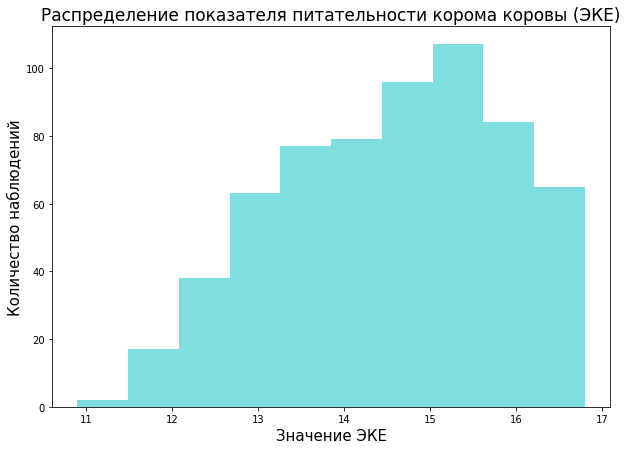

In [55]:
plt.figure(figsize=(10, 7))
plt.hist(df_main['energy_feed_unit'], bins=10, color='c', alpha=0.5)
plt.xlabel('Значение ЭКЕ', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение показателя питательности корома коровы (ЭКЕ)', size=17)
plt.show()

In [56]:
df_main['energy_feed_unit'].describe()

count    628.000000
mean      14.548726
std        1.301777
min       10.900000
25%       13.500000
50%       14.700000
75%       15.600000
max       16.800000
Name: energy_feed_unit, dtype: float64

Распределение показателя питательности корма смещено вправо. Оно похоже на нормальное распраделение, пик которого смещен. Аномально выбивающихся значений в данных не обнаружено. Значение питательности корма коровы находятся в диапазоне от 10 до 17 единиц. 

*3. Содержание сырого протеина в корме (crude_protein_ratio)*

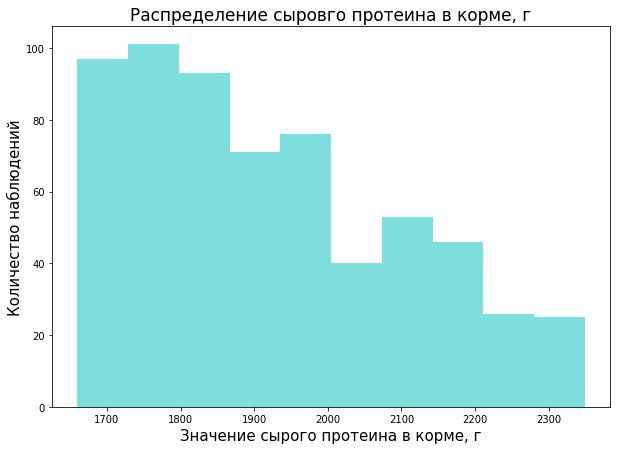

In [57]:
plt.figure(figsize=(10, 7))
plt.hist(df_main['crude_protein_g'], bins=10, color='c', alpha=0.5)
plt.xlabel('Значение сырого протеина в корме, г', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение сыровго протеина в корме, г', size=17)
plt.show()

In [58]:
df_main['crude_protein_g'].describe()

count     628.000000
mean     1923.759554
std       182.832816
min      1660.000000
25%      1771.750000
50%      1888.000000
75%      2062.250000
max      2349.000000
Name: crude_protein_g, dtype: float64

На гистограмме выше аномальных значений в данных не наблюдается. Распределение скошено влево. График не похож на нормальное распределение. Значение сырого протеина в корме коров варьируется от 1660 до 2349 грамм. 

*4. Сахарно-протеиновое соотношение (sugar_protein_ratio)*

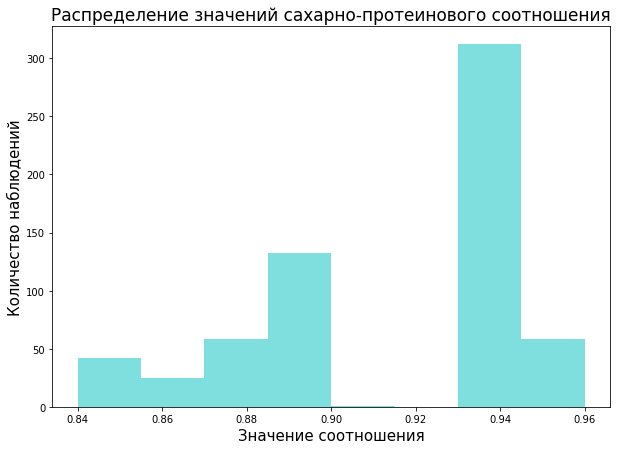

In [59]:
plt.figure(figsize=(10, 7))
plt.hist(df_main['sugar_protein_ratio'], bins=8, color='c', alpha=0.5)
plt.xlabel('Значение соотношения', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение значений сахарно-протеинового соотношения', size=17)
plt.show()

In [60]:
df_main['sugar_protein_ratio'].describe()

count    628.000000
mean       0.913089
std        0.032221
min        0.840000
25%        0.890000
50%        0.930000
75%        0.940000
max        0.960000
Name: sugar_protein_ratio, dtype: float64

Как видно на графике выше, аномалий в данных нет. Соотношение сахара к протеину в корме коров составляет от 0.84 до 0.96. Большая часть коров питаются кормом с соотношением сахара к протеину больше 0.9. Распределение не похоже на нормальное: выделяются два пика в районе значений 0.88-0.90 и 0.94.

*5. Порода (breed)*

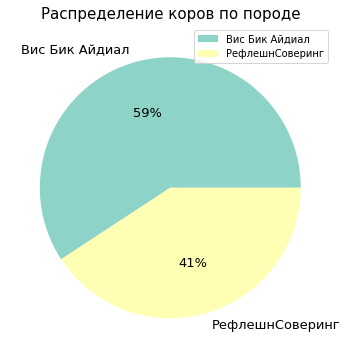

In [61]:
(df_main
 .pivot_table(index='breed', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='breed', y='id', figsize=(10,6), labels=df_main['breed'].unique(), autopct = "%.0f%%", ylabel='',\
      textprops={'fontsize':13}, colors=sns.color_palette('Set3'))
)
plt.title('Распределение коров по породе', size=15)
plt.show()

На диаграмме выше видно, что на текущий момент пологовье на 60% состоит из коров породы Вис Бик Айдиал, и на 40% из породы РефлешнСоверинг.

*6. Тип пастбища (pasture_type)*

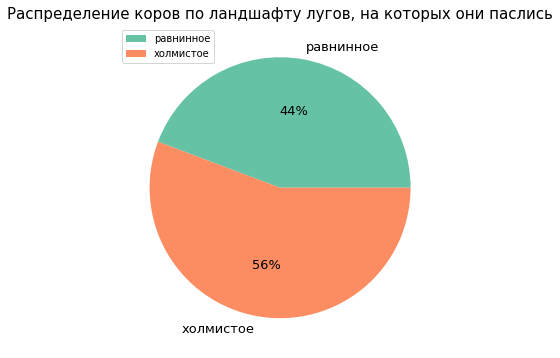

In [62]:
(df_main
 .pivot_table(index='pasture_type', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='pasture_type', y='id', figsize=(10,6), labels=df_main['pasture_type'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper left')
plt.title('Распределение коров по ландшафту лугов, на которых они паслись', size=15)
plt.show()

Распределение коров между двумя типами пастбищ практически одинаковое. Чуть больше коров паслись на холмистых пастбищах.

*7. Порода папы коровы (fathers_breed)*

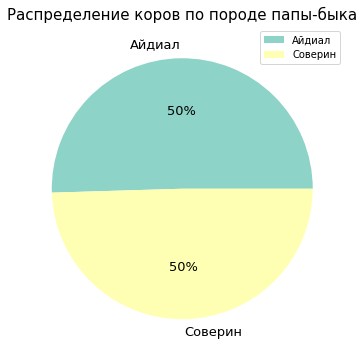

In [63]:
(df_main
 .pivot_table(index='fathers_breed', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='fathers_breed', y='id', figsize=(10,6), labels=df_main['fathers_breed'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set3'))
)
plt.title('Распределение коров по породе папы-быка', size=15)
plt.show()

Ровно у половины поголовья скота порода папы-быка была Айдиал, у другой половины - Соверин.

*8. Жирность (fat_%)*

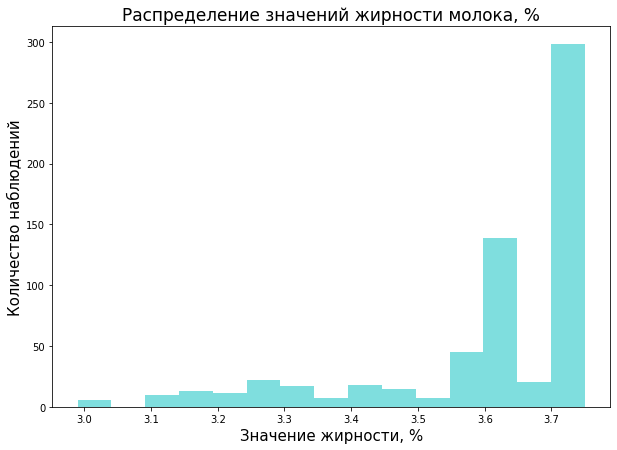

In [64]:
plt.figure(figsize=(10, 7))
plt.hist(df_main['fat_%'], bins=15, color='c', alpha=0.5)
plt.xlabel('Значение жирности, %', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение значений жирности молока, %', size=17)
plt.show()

In [65]:
df_main['fat_%'].describe()

count    628.000000
mean       3.604268
std        0.168093
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat_%, dtype: float64

Поголовье фермера дает молоко с процентом жирности от 3 до 4. Чаще всего получаемое молоко обладает процентом жирности от 3.6%
Распределение не похоже на нормальное: видно два пика - один в райное значения 3.6, другой в районе значения 3.7. Также есть длинный "хвост" слева  со значениями меньше 3.5

*9. Содержание протеина (protein_%)*

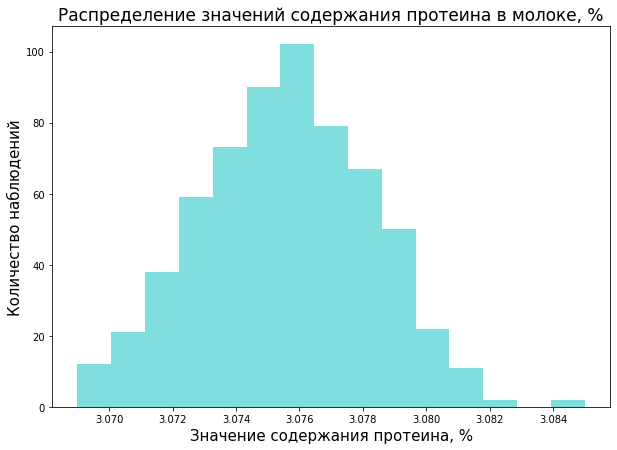

In [66]:
plt.figure(figsize=(10, 7))
plt.hist(df_main['protein_%'], bins=15, color='c', alpha=0.5)
plt.xlabel('Значение содержания протеина, %', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение значений содержания протеина в молоке, %', size=17)
plt.show()

In [67]:
df_main['protein_%'].describe()

count    628.000000
mean       3.075670
std        0.002551
min        3.069000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.085000
Name: protein_%, dtype: float64

Распределение содержания протеина в молоке похоже на нормальное. Протеин колеблется на уровне 3%. Аномальных значений в данных нет.

*10. Вкус молока (milk_taste)*

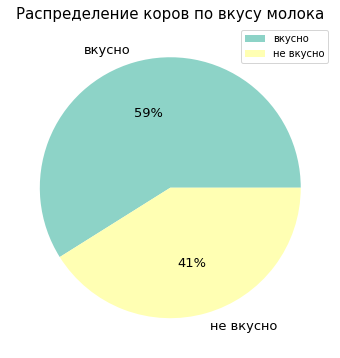

In [68]:
(df_main
 .pivot_table(index='milk_taste', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='milk_taste', y='id', figsize=(10,6), labels=df_main['milk_taste'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set3'))
)
plt.title('Распределение коров по вкусу молока', size=15)
plt.show()

Среди поголовья скота фермера около 60% дают вкусное молоко, около 40% - не вкусное.

*11. Возраст (age)*

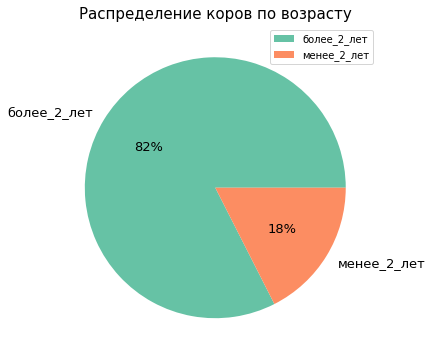

In [69]:
(df_main
 .pivot_table(index='age', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='age', y='id', figsize=(10,6), labels=df_main['age'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.title('Распределение коров по возрасту', size=15)
plt.show()

Среди коров фермера преобладают коровы возрастом более 2 лет - 82%.

Таким образом, были исследованы все признаки поголовья скота в датасете `df_main`.

**Выводы:**
- Выбросы в данных были обнаружены в значениях удоя (milk_yield_kg). Аномальные значения были обработаны.
- Значения удоя у коров распределены в диапазоне от 5204 кг/год до 7222 кг/год.
- Распределение показателя питательности корма смещено вправо. Аномально выбивающихся значений в данных не обнаружено. Значение питательности корма коровы находятся в диапазоне от 10 до 17 единиц.
- Значение сырого протеина в корме коров варьируется от 1660 до 2349 грамм.
- Соотношение сахара к протеину в корме коров составляет от 0.84 до 0.96. Большая часть коров питаются кормом с соотношением сахара к протеину больше 0.9.
- На текущий момент пологовье на 60% состоит из коров породы Вис Бик Айдиал, и на 40% из породы РефлешнСоверинг.
- Распределение коров между двумя типами пастбищ практически одинаковое. Чуть больше коров паслись на холмистых пастбищах.
- Ровно у половины поголовья скота порода папы-быка была Айдиал, у другой половины - Соверин.
- Поголовье фермера дает молоко с процентом жирности от 3 до 4. Чаще всего получаемое молоко обладает процентом жирности от 3.6%
- Распределение содержания протеина в молоке похоже на нормальное. Протеин колеблется на уровне 3%. 
- Среди поголовья скота фермера около 60% дают вкусное молоко, около 40% - не вкусное.
- Среди коров фермера преобладают коровы возрастом более 2 лет - 82%.
- Некоторые количественные признаки распределены не нормально, а именно - sugar_protein_ratio, fat_%, crude_protein_g

### Статичстический анализ признаков в датафрейме df_dad

Проанализируем каждый из признаков датафрейма df_dad и посмотрим, как распределяются значения, есть ли в данных аномалии и как их можно обработать.

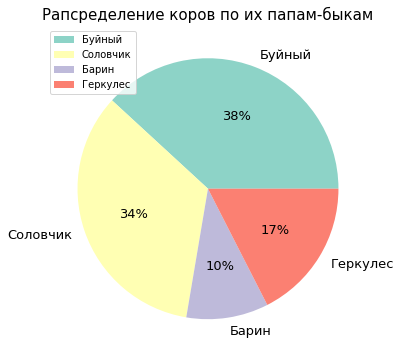

In [70]:
(df_dad
 .pivot_table(index='fathers_name', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='fathers_name', y='id', figsize=(10,6), labels=df_dad['fathers_name'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set3'))
)
plt.legend(loc='upper left')
plt.title('Рапсределение коров по их папам-быкам', size=15)
plt.show()

Большая часть коров в поголовье рождены от Буйного и Соловчика (38% и 34% соответственно). Меньше коров рождены от Геркулеса - 17%. Меньше всего коров рождены от Барина - 10%.

### Статичстический анализ признаков в датафрейме df_buy

Проанализируем каждый из признаков датафрейма df_dad и посмотрим, как распределяются значения, есть ли в данных аномалии и как их можно обработать.

*1. Порода коров (breed)*

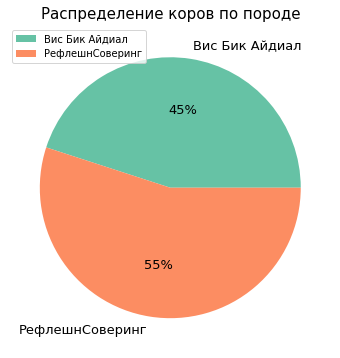

In [71]:
(df_buy
 .pivot_table(index='breed', values='pasture_type', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='breed', y='pasture_type', figsize=(10,6), labels=df_buy['breed'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper left')
plt.title('Распределение коров по породе', size=15)
plt.show()

Чуть больше половины коров, предлагаемых к покупке, породы РфлешнСоверинг, другая половина (чуть меньше) - Вис Бик Айдиал.

*2. Тип пастбища (pasture_type)*

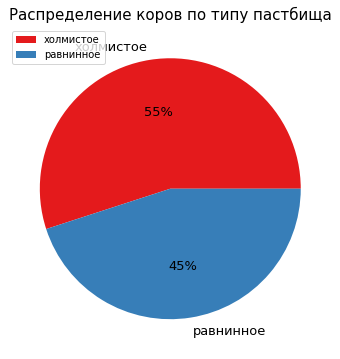

In [72]:
(df_buy
 .pivot_table(index='pasture_type', values='breed', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='pasture_type', y='breed', figsize=(10,6), labels=df_buy['pasture_type'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set1'))
)
plt.legend(loc='upper left')
plt.title('Распределение коров по типу пастбища', size=15)
plt.show()

Чуть большая половина коров, предлагаемых к покупке, пасутся на холмистых пастбищах, другая часть - на равнинных.

*3. Порода папы-быка (fathers_breed)*

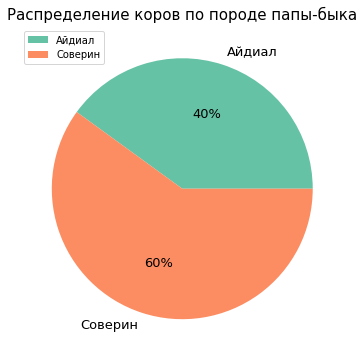

In [73]:
(df_buy
 .pivot_table(index='fathers_breed', values='breed', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='fathers_breed', y='breed', figsize=(10,6), labels=df_buy['fathers_breed'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper left')
plt.title('Распределение коров по породе папы-быка', size=15)
plt.show()

Большая часть коров, предлагаемых к покупке, рождены от быков породы Соверин.

*4. Имя папы-быка (fathers_name)*

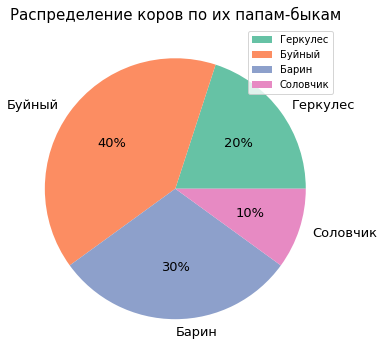

In [74]:
(df_buy
 .pivot_table(index='fathers_name', values='breed', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='fathers_name', y='breed', figsize=(10,6), labels=df_buy['fathers_name'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper right')
plt.title('Распределение коров по их папам-быкам', size=15)
plt.show()

Большинство коров на продажу рождены от Буйного (40%) и Барина (30%).

*5. Жирность (fat_%)*

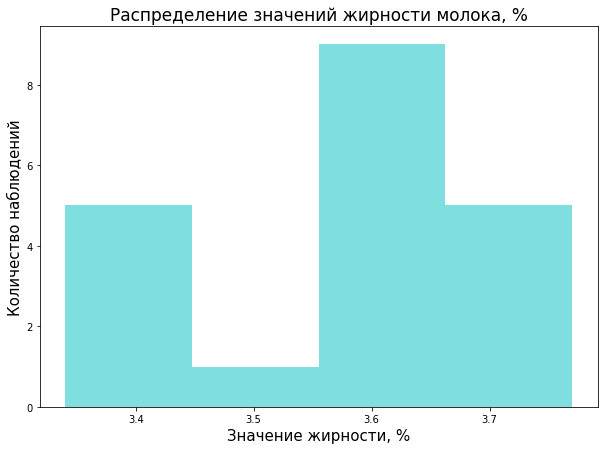

In [75]:
plt.figure(figsize=(10, 7))
plt.hist(df_buy['fat_%'], bins=4, color='c', alpha=0.5)
plt.xlabel('Значение жирности, %', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение значений жирности молока, %', size=17)
plt.show()

In [76]:
df_buy['fat_%'].describe()

count    20.000000
mean      3.577500
std       0.126818
min       3.340000
25%       3.510000
50%       3.590000
75%       3.650000
max       3.770000
Name: fat_%, dtype: float64

Жирность молока, которую дают коровы, распределена от 3.34% до 3.77%. Аномальных значений в данных не выявлено.

*6. Содержание протеина (protein_%)*

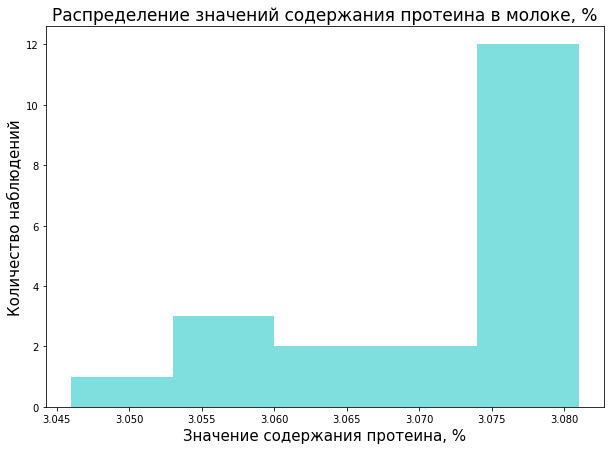

In [77]:
plt.figure(figsize=(10, 7))
plt.hist(df_buy['protein_%'], bins=5, color='c', alpha=0.5)
plt.xlabel('Значение содержания протеина, %', size=15)
plt.ylabel('Количество наблюдений', size=15)
plt.title('Распределение значений содержания протеина в молоке, %', size=17)
plt.show()

In [78]:
df_buy['protein_%'].describe()

count    20.000000
mean      3.069500
std       0.010339
min       3.046000
25%       3.064000
50%       3.074000
75%       3.076000
max       3.081000
Name: protein_%, dtype: float64

Содержание протеина в молоке колеблется от 3.04% до 3.08% (разброс значений минимальный). Аномалий в данных не обнаружено).

*7. Возраст (age)*

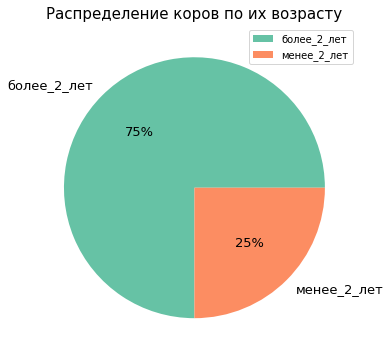

In [79]:
(df_buy
 .pivot_table(index='age', values='breed', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='age', y='breed', figsize=(10,6), labels=df_buy['age'].unique(), autopct = "%.0f%%",\
       ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper right')
plt.title('Распределение коров по их возрасту', size=15)
plt.show()

Большинство коров, предлагаемых к покупке, возрастом более 2 лет.

**Выводы:**
- Аномальные значения в данных в датасете df_buy отсутствуют.
- В датасете df_buy половина коров, предлагаемых к покупке, породы РфлешнСоверинг, другая половина - Вис Бик Айдиал.
- Половина коров, предлагаемых к покупке, пасутся на равнинных пастбищах, другая половина - на холмистых.
- Большая часть коров, предлагаемых к покупке, рождены от быков породы Соверин.
- Большинство коров на продажу рождены от Буйного (44%) и Барина (31%).
- Жирность молока, которую дают коровы, распределена от 3.34% до 3.77%.
- Содержание протеина в молоке колеблется от 3.04% до 3.08% (разброс значений жирности минимальный).
- Большинство коров, предлагаемых к покупке, возрастом более 2 лет.
- Признаки, распределение которых похоже на нормальное: milk_yield_kg, energy_feed_unit, protein_%
- Признаки, распределение которых не похоже на нормальное: fat_%, sugar_protein_ratio, crude_protein_g

## Корреляционный анализ
<a id="corr"></a>

### Взаимосвязь между признаками в датафрейме df_main

Изучим взаимосвязь между признаками в датафрейме df_main с помощью определения коэффициентов корреляции. 
Для нагляднсоти построим тепловую карту матрицы корреляции.

Так как некоторые признаки имеют не нормальное распределение, то вместо корреляции Пирсона используем корреляцию Спирмана.

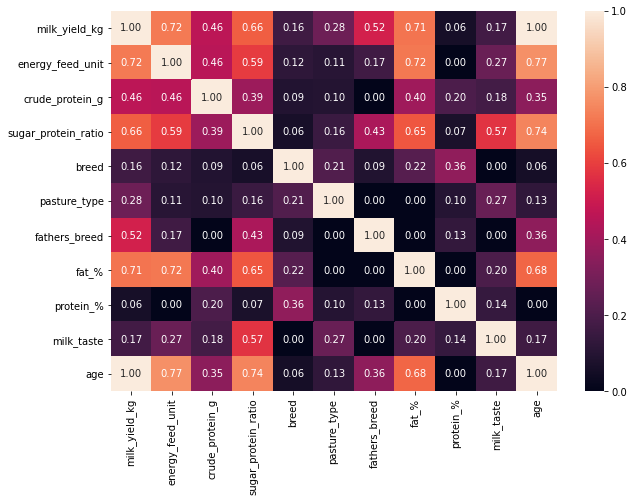

In [80]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_main.drop(['id'], axis=1).phik_matrix(interval_cols=['milk_yield_kg', 'energy_feed_unit', 'crude_protein_g',\
                                        'sugar_protein_ratio', 'fat_%', 'protein_%']), annot=True, fmt='.2f')
plt.show()

Таким образом, коэффициенты корреляции для целевого признака с входными признаками: 

**Умеренная (0.3 - 0.5)** корреляция наблюдается c признаками:
- сырой протеин в корме (crude_protein_g): 0.46

**Заметная (0.5 - 0.7)** корреляция наблюдается с признаками:
- СПО (sugar_protein_ratio): 0.66
- порода папы коровы (fathers_breed): 0.52

**Высокая (0.7 - 0.9)** корреляция наблюдается с признаками:
- ЭКЕ (eneergy_feed_unit): 0.72
- жирность (fat_%): 0.71
- возраст коровы (age): 1.0

Чтобы более детально оценить корреляцию целевого и входных признаков между собой, построим диаграммы рассеяния, учитывающие категориальные признаки.

### Диаграммы рассеяния

#### *1. Удой (milk_yield_kg) и ЭКЕ (energy_feed_unit)*

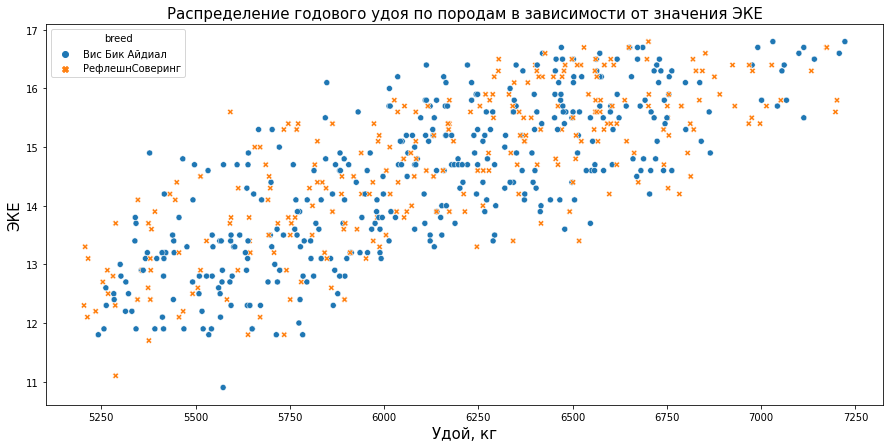

In [81]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='energy_feed_unit', hue = 'breed', style = 'breed', data = df_main)
plt.ylabel('ЭКЕ', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по породам в зависимости от значения ЭКЕ', size=15)
plt.show()

Между признаками удой и питательность корма видна зависимость похожая на среднее между линейной и квадратичной, одинаковая для обоих пород коров. 

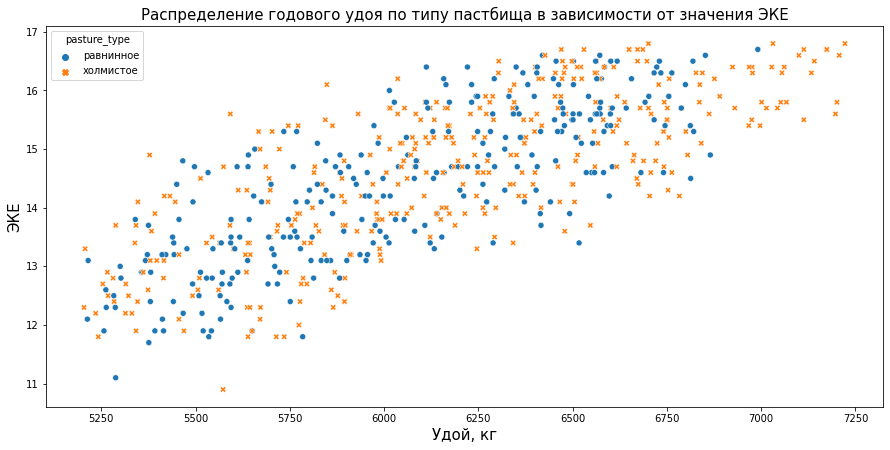

In [82]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='energy_feed_unit', hue = 'pasture_type', style = 'pasture_type', data = df_main)
plt.ylabel('ЭКЕ', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по типу пастбища в зависимости от значения ЭКЕ', size=15)
plt.show()

Зависимость между исследуемыми количественными признаками не зависит от типа пастбища.

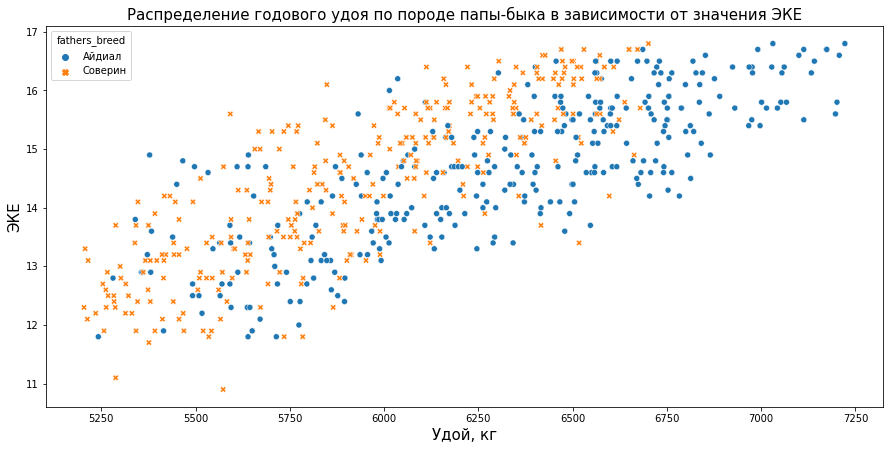

In [83]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='energy_feed_unit', hue = 'fathers_breed', style = 'fathers_breed', data = df_main)
plt.ylabel('ЭКЕ', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по породе папы-быка в зависимости от значения ЭКЕ', size=15)
plt.show()

На графике выше видны различия между породами папы-быка: при одинаковом значении питательности корма больше удой тех коров, у которых порода папы-быка Айдиал. 

Также, есть данные по имени папы-быка в отдельном датафрейме, объединим два датасета и посмотрим, на получившееся распределение.

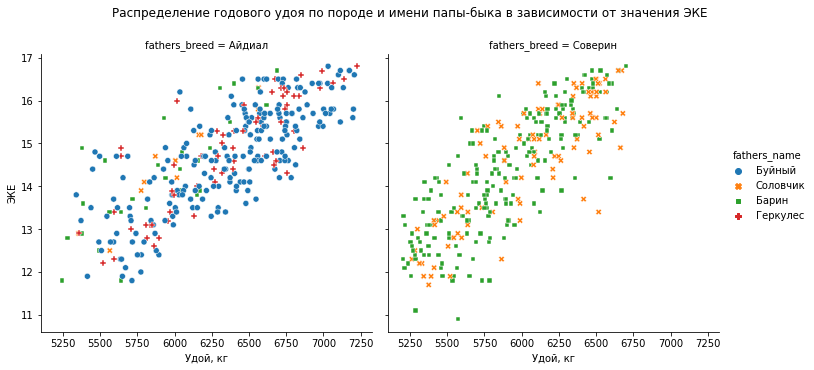

In [84]:
scatter = sns.relplot(data = df_main.merge(df_dad, how='right', on='id'),x ='milk_yield_kg', \
           y ='energy_feed_unit', col='fathers_breed', hue = 'fathers_name', style = 'fathers_name', kind='scatter')
scatter.fig.subplots_adjust(top=0.85)
scatter.fig.suptitle('Распределение годового удоя по породе и имени папы-быка в зависимости от значения ЭКЕ', size=12)
scatter.set_axis_labels('Удой, кг', 'ЭКЕ')

plt.show()

Выявилась проблема в данных: если посмотреть на диаграммы рассеяния, то быки с именами Барин и Соловчик одновременно являются быками породы Айдиал и Соверин, чего быть не может. Попробуем обработать эти значения.

In [85]:
data = df_main.merge(df_dad, how='right', on='id')
print('Барин породы соверин:',data[(data['fathers_name']=='Барин')&(data['fathers_breed']=='Соверин')]['id'].count())
print('Барин породы айдиал:', data[(data['fathers_name']=='Барин')&(data['fathers_breed']=='Айдиал')]['id'].count())

Барин породы соверин: 212
Барин породы айдиал: 28


In [86]:
print('Соловчик породы соверин:',data[(data['fathers_name']=='Соловчик')&(data['fathers_breed']=='Соверин')]['id'].count())
print('Соловчик породы айдиал:', data[(data['fathers_name']=='Соловчик')&(data['fathers_breed']=='Айдиал')]['id'].count())

Соловчик породы соверин: 99
Соловчик породы айдиал: 11


Возможно, при заполнении исходных данных произошла ошибка: либо правильно указали имя и неправильно породу папы коровы, либо наоборот. Так как основная масса и у Соловчика, и у Барина относится к породе Соверин, то предположим, что записи породы Айдиал были ошибочны. Внесем изменения в датасет, чтобы исправить выявленную аномалию.

In [87]:
for ind in df_dad[df_dad['fathers_name']=='Соловчик']['id']:
    df_main.loc[df_main['id']==ind, 'fathers_breed'] = 'Соверин'

In [88]:
for ind in df_dad[df_dad['fathers_name']=='Барин']['id']:
    df_main.loc[df_main['id']==ind, 'fathers_breed'] = 'Соверин'

In [89]:
# проверка
data = df_main.merge(df_dad, how='right', on='id')
print('Барин породы соверин:',data[(data['fathers_name']=='Барин')&(data['fathers_breed']=='Соверин')]['id'].count())
print('Барин породы айдиал:', data[(data['fathers_name']=='Барин')&(data['fathers_breed']=='Айдиал')]['id'].count())

Барин породы соверин: 240
Барин породы айдиал: 0


In [90]:
# проверка
print('Соловчик породы соверин:',data[(data['fathers_name']=='Соловчик')&(data['fathers_breed']=='Соверин')]['id'].count())
print('Соловчик породы айдиал:', data[(data['fathers_name']=='Соловчик')&(data['fathers_breed']=='Айдиал')]['id'].count())

Соловчик породы соверин: 110
Соловчик породы айдиал: 0


С учетом обновления данных заново построим диаграмму рассеяния:

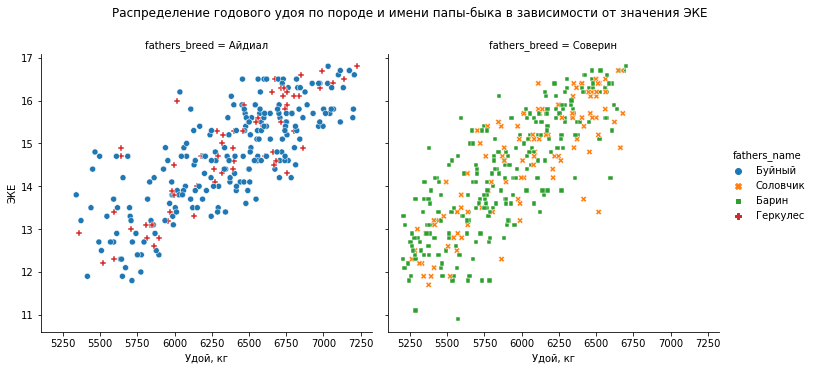

In [91]:
scatter = sns.relplot(data = df_main.merge(df_dad, how='right', on='id'),x ='milk_yield_kg', \
           y ='energy_feed_unit', col='fathers_breed', hue = 'fathers_name', style = 'fathers_name', kind='scatter')
scatter.fig.subplots_adjust(top=0.85)
scatter.fig.suptitle('Распределение годового удоя по породе и имени папы-быка в зависимости от значения ЭКЕ', size=12)
scatter.set_axis_labels('Удой, кг', 'ЭКЕ')

plt.show()

Тепрь все логично: каждому одному имени соответствует одно значение породы. На обоих графиках прослеживается зависимость между удоем и ЭКЕ: чем выше значение ЭКЕ, тем выше удой. При этом "облако" данных породы Айдиал смещено ближе к максимальному значению удоя, а "облако" Соверин - ближе к минимальному.

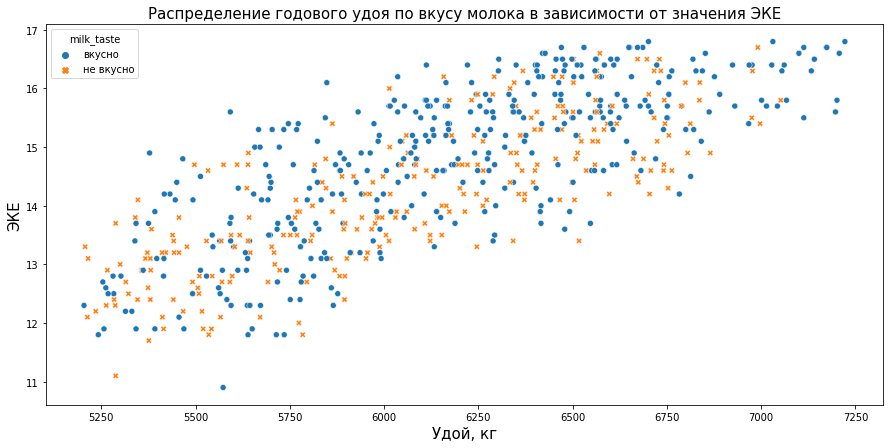

In [92]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='energy_feed_unit', hue = 'milk_taste', style = 'milk_taste', data = df_main)
plt.ylabel('ЭКЕ', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по вкусу молока в зависимости от значения ЭКЕ', size=15)
plt.show()

Одинаковая линейная зависимость ЭКЕ и значения удоя как у вкусного молока, так и у не вкусного.

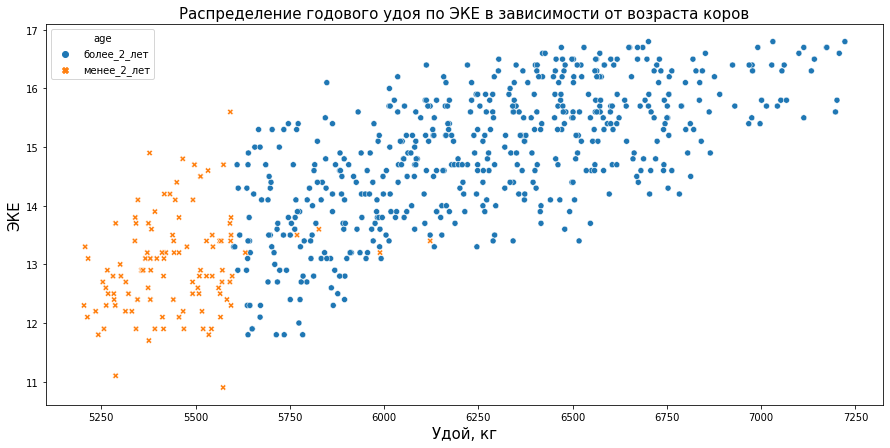

In [93]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='energy_feed_unit', hue = 'age', style = 'age', data = df_main)
plt.ylabel('ЭКЕ', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по ЭКЕ в зависимости от возраста коров', size=15)
plt.show()

Четко видно, что у коров возрастом менее двух лет вне зависимости от значения ЭКЕ меньше удой, чем у коров возрастом более 2 лет. У коров старше двух лет видна линейная зависимость ЭКЕ и удоя.

#### *2. Удой и значение сырого протеина в корме*

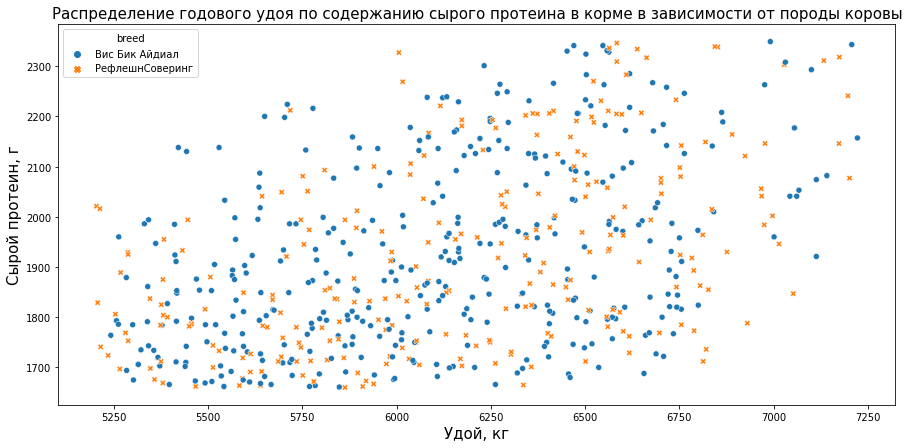

In [94]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='crude_protein_g', hue = 'breed', style = 'breed', data = df_main)
plt.ylabel('Сырой протеин, г', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию сырого протеина в корме в зависимости от породы коровы', size=15)
plt.show()

Отношение удоя и содержания сырого протеина в корме не зависит от породы коровы. Судя по графику в целом линейная взаимосвязь между указанными признаками слабая.

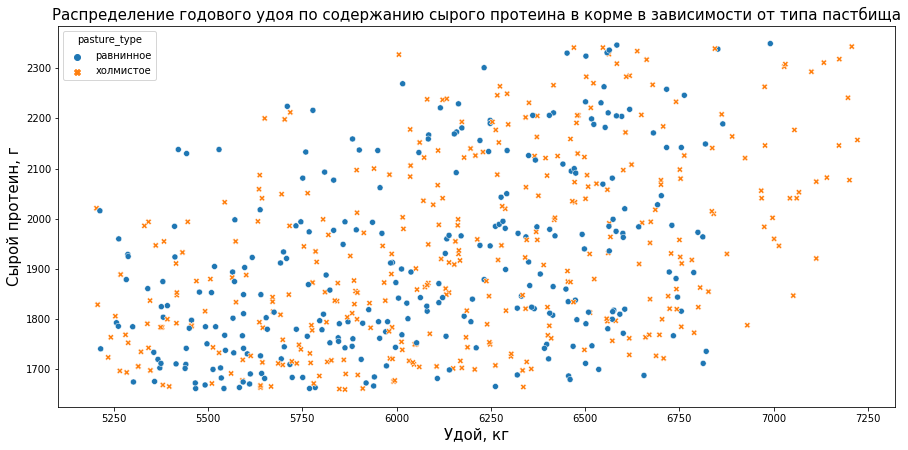

In [95]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='crude_protein_g', hue = 'pasture_type', style = 'pasture_type', data = df_main)
plt.ylabel('Сырой протеин, г', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию сырого протеина в корме в зависимости от типа пастбища', size=15)
plt.show()

Тип пастбища не влияет на распределение удоя от сырого протеина. При этом коровы с удоем больше 7000 пасутся на холмистых пастбищах.

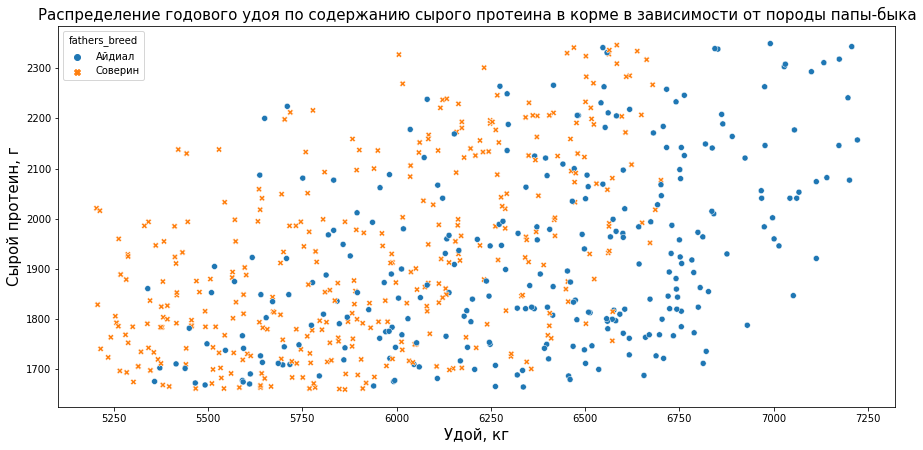

In [96]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='crude_protein_g', hue = 'fathers_breed', style = 'fathers_breed', data = df_main)
plt.ylabel('Сырой протеин, г', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию сырого протеина в корме в зависимости от породы папы-быка', size=15)
plt.show()

На графике выше видна слабая линейная зависимость как у породы Айдиал, так и Соверин. При этом вне зависимости от содержания сырого протеина в корме, удой свыше 6750 кг демонстрируют только коровы, рожденные от породы Айдиал.

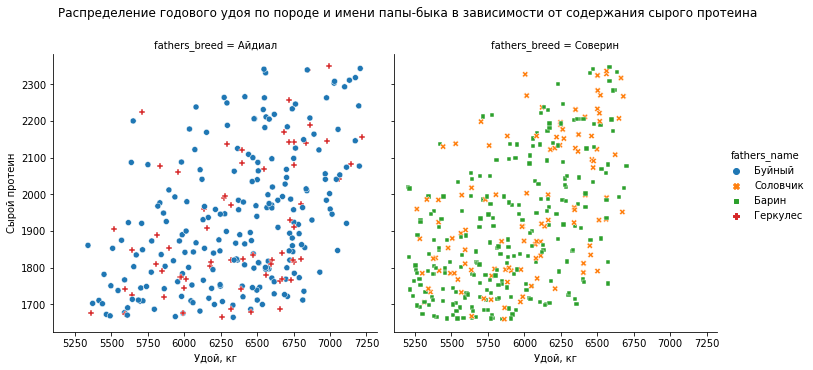

In [97]:
scatter = sns.relplot(data = df_main.merge(df_dad, how='right', on='id'),x ='milk_yield_kg', \
           y ='crude_protein_g', col='fathers_breed', hue = 'fathers_name', style = 'fathers_name', kind='scatter')
scatter.fig.subplots_adjust(top=0.85)
scatter.fig.suptitle('Распределение годового удоя по породе и имени папы-быка в зависимости от содержания сырого протеина', size=12)
scatter.set_axis_labels('Удой, кг', 'Сырой протеин')

plt.show()

Видно, что отношение удой/сырой протеин одинаковое для быков, объединенных по признаку порода. Внутри одной породы распределение не зависит от того, какой конкретно бык.

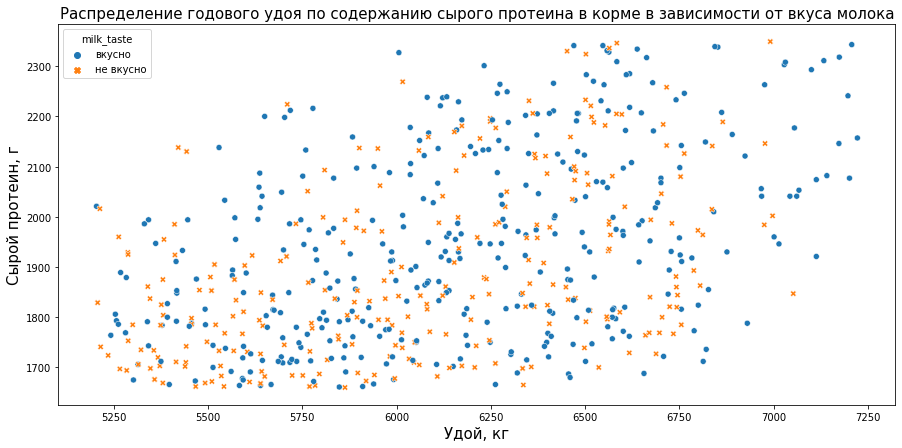

In [98]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='crude_protein_g', hue = 'milk_taste', style='milk_taste', data = df_main)
plt.ylabel('Сырой протеин, г', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию сырого протеина в корме в зависимости от вкуса молока', size=15)
plt.show()

При любом соотношении удоя и сырого протеина в корме молоко может быть как вкусным, так и не вкусным.

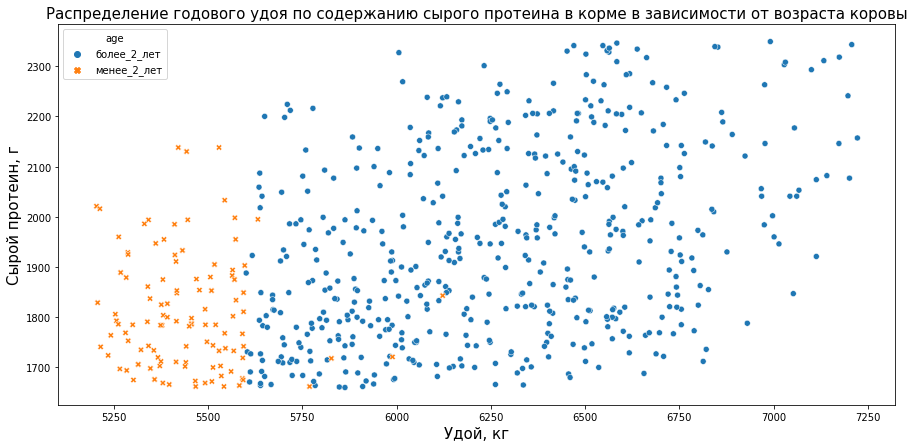

In [99]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='crude_protein_g', hue = 'age', style='age', data = df_main)
plt.ylabel('Сырой протеин, г', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию сырого протеина в корме в зависимости от возраста коровы', size=15)
plt.show()

В распределении у коров возрастом до 2 лет есть выбросы с аномально высоким удоем. В целом, при одном и том же значении сырого протеина в корме, значение удоя больше у коров старше 2 лет.

#### *3. Удой и соотношение сахара к протеину в корме коровы*

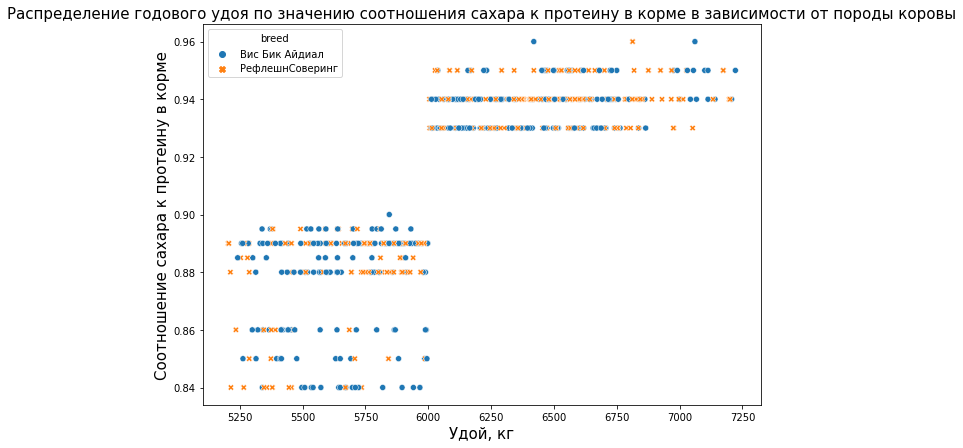

In [100]:
plt.figure(figsize=(10,7))
sns.scatterplot(x ='milk_yield_kg', y ='sugar_protein_ratio', hue = 'breed', style='breed', data = df_main)
plt.ylabel('Соотношение сахара к протеину в корме', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению соотношения сахара к протеину в корме в зависимости от породы коровы', \
          size=15)
plt.show()

Видно, что вне зависимости от породы коровы, значение удоя будет выше, при соотношении сахара к протеину в корме больше 0.9.
Зависимость не линейная.

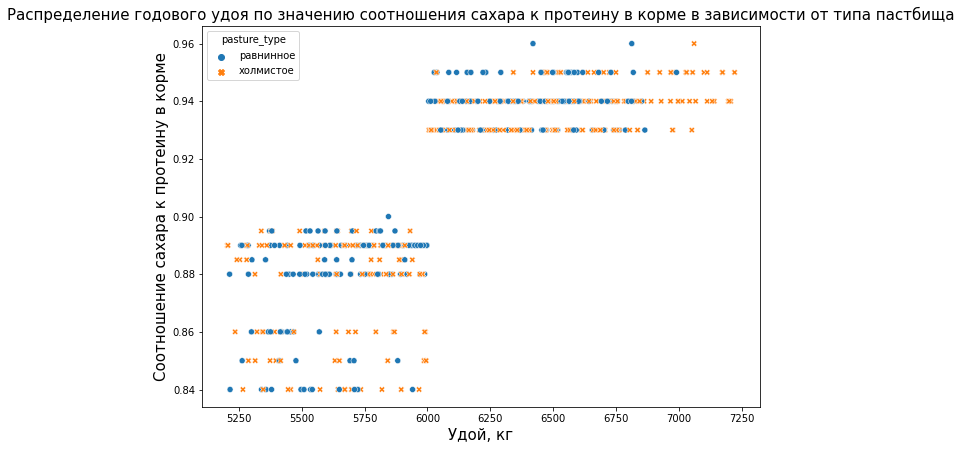

In [101]:
plt.figure(figsize=(10,7))
sns.scatterplot(x ='milk_yield_kg', y ='sugar_protein_ratio', hue = 'pasture_type', style='pasture_type', data = df_main)
plt.ylabel('Соотношение сахара к протеину в корме', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению соотношения сахара к протеину в корме в зависимости от типа пастбища', \
          size=15)
plt.show()

Среди коров, у которых соотношения сахара к протеину в корме меньше 0.86 и больше 0.9, преобладает тип пастбища холмистое.

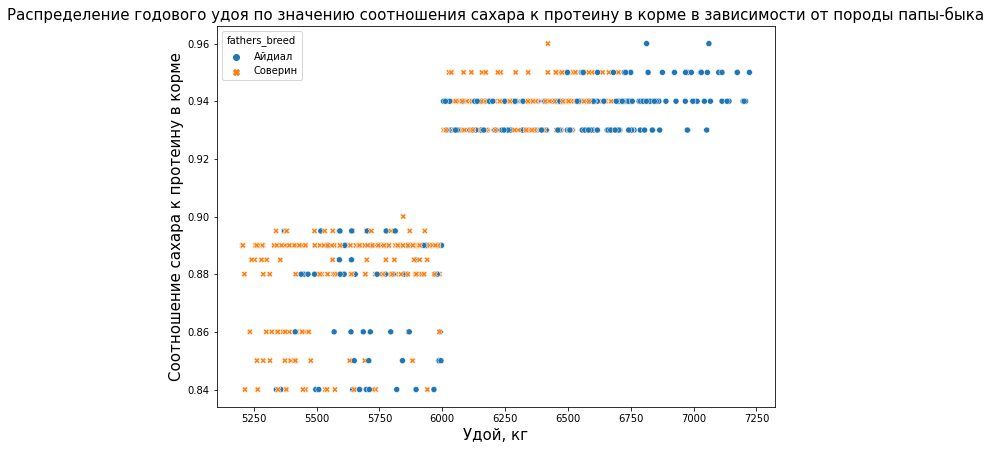

In [102]:
plt.figure(figsize=(10,7))
sns.scatterplot(x ='milk_yield_kg', y ='sugar_protein_ratio', hue = 'fathers_breed', style='fathers_breed', data = df_main)
plt.ylabel('Соотношение сахара к протеину в корме', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению соотношения сахара к протеину в корме в зависимости от породы папы-быка', \
          size=15)
plt.show()

Среди коров, у которых соотношение сахара к протеину в корме больше 0.9, при одном и том же значении соотношения удой больше у коров рожденных от породы Айдиал.

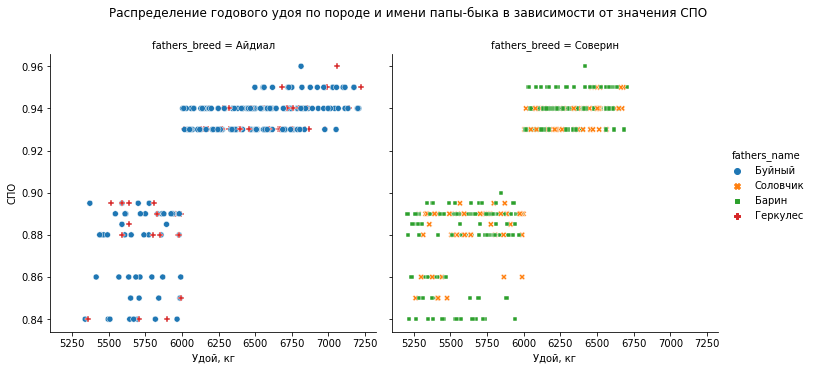

In [103]:
scatter = sns.relplot(data = df_main.merge(df_dad, how='right', on='id'),x ='milk_yield_kg', \
           y ='sugar_protein_ratio', col='fathers_breed', hue = 'fathers_name', style = 'fathers_name', kind='scatter')
scatter.fig.subplots_adjust(top=0.85)
scatter.fig.suptitle('Распределение годового удоя по породе и имени папы-быка в зависимости от значения СПО', size=12)
scatter.set_axis_labels('Удой, кг', 'СПО')

plt.show()

Графики подкрепляют выводы относительно пород, сделанные в блоке выше.

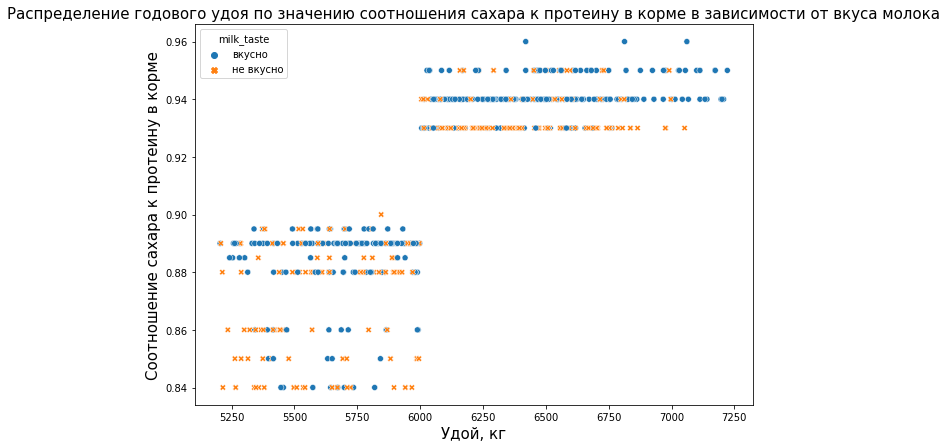

In [104]:
plt.figure(figsize=(10,7))
sns.scatterplot(x ='milk_yield_kg', y ='sugar_protein_ratio', hue = 'milk_taste', style='milk_taste', data = df_main)
plt.ylabel('Соотношение сахара к протеину в корме', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению соотношения сахара к протеину в корме в зависимости от вкуса молока', \
          size=15)
plt.show()

Вне зависимости от удоя, чаще вкусное молоко было у коров с соотношением сахара к протеину в корме от 0.88 до 0.90 и больше 0.94.

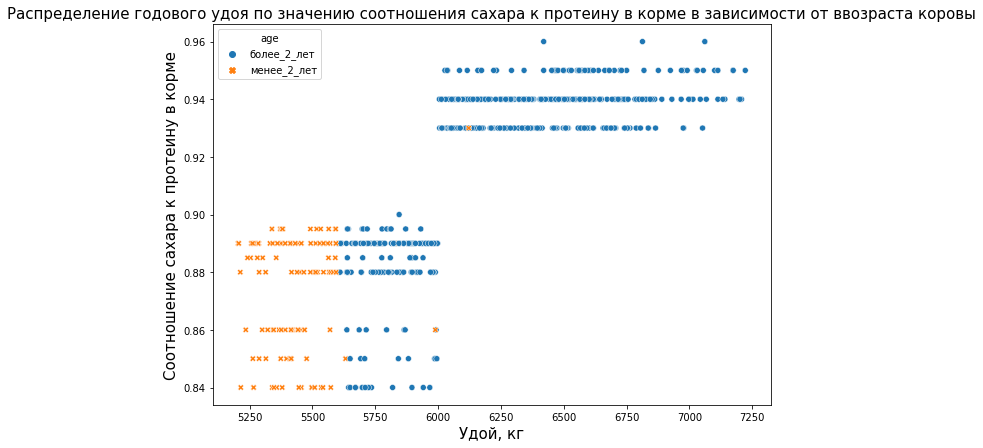

In [105]:
plt.figure(figsize=(10,7))
sns.scatterplot(x ='milk_yield_kg', y ='sugar_protein_ratio', hue = 'age', style='age', data = df_main)
plt.ylabel('Соотношение сахара к протеину в корме', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению соотношения сахара к протеину в корме в зависимости от ввозраста коровы', \
          size=15)
plt.show()

Коровы возрастом до 2 лет питаются кормом, в котором соотношение сахара к протеину не превышает 0.90. При этом, если рассматривать отрезок со значением соотношения от 0.84 до 0.90, то видно, что удой коров возрастом более двух лет будет больше, чем коров возрастом менее двух лет.

#### *4. Удой и процент жирности*

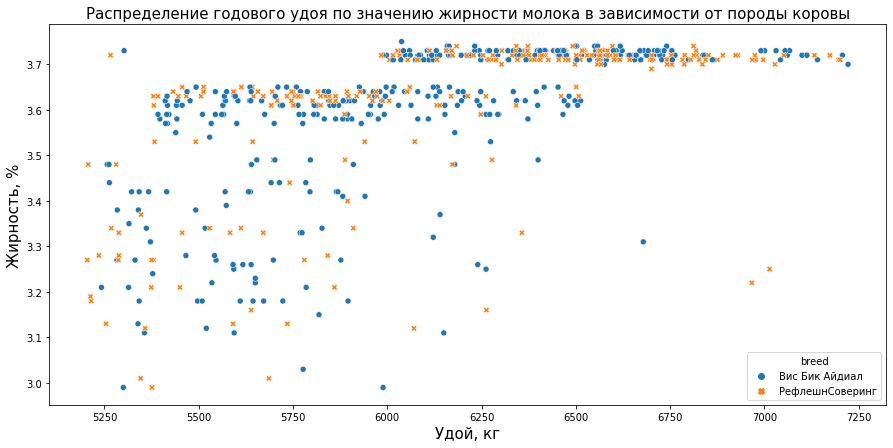

In [106]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='fat_%', hue = 'breed', style='breed', data = df_main)
plt.ylabel('Жирность, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению жирности молока в зависимости от породы коровы', size=15)
plt.show()

Различий по породе коровы в распределении удоя в зависимости от жирности не наблюдается. Каждое значение пары удой-жирность представлено примерно одинаково обеими породами.

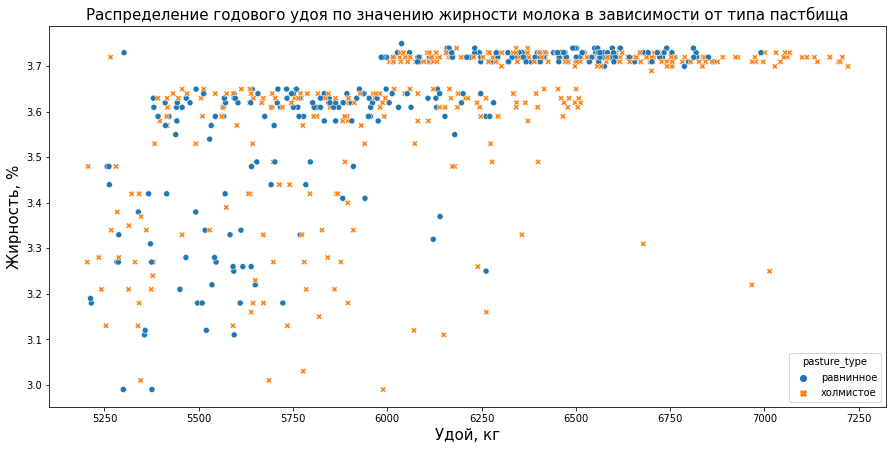

In [107]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='fat_%', hue = 'pasture_type', style='pasture_type', data = df_main)
plt.ylabel('Жирность, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению жирности молока в зависимости от типа пастбища', size=15)
plt.show()

Каждое значение пары удой-жирность представлено примерно одинаково обоими типами пастбищ. 

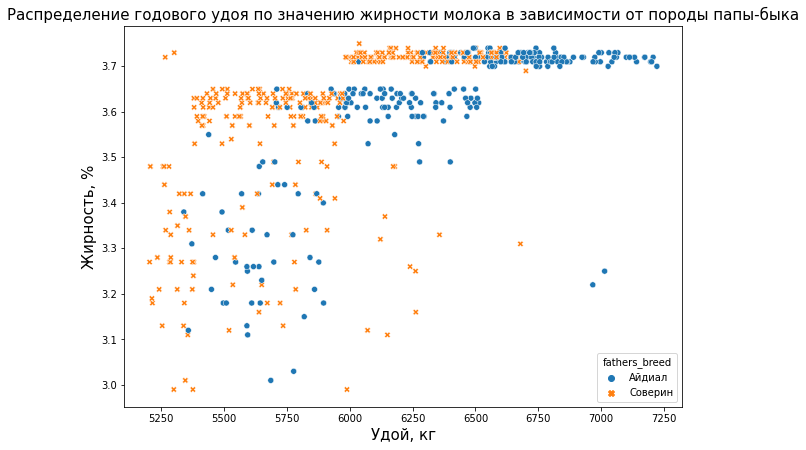

In [108]:
plt.figure(figsize=(10,7))
sns.scatterplot(x ='milk_yield_kg', y ='fat_%', hue = 'fathers_breed', style='fathers_breed', data = df_main)
plt.ylabel('Жирность, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению жирности молока в зависимости от породы папы-быка', size=15)
plt.show()

Обе породы чаще всего дают молоко жирность более 3.5%. При этом, у коров, рожденных от породы Айдиал, при одной и той же жирности значение удоя больше, чем у породы Соверин.

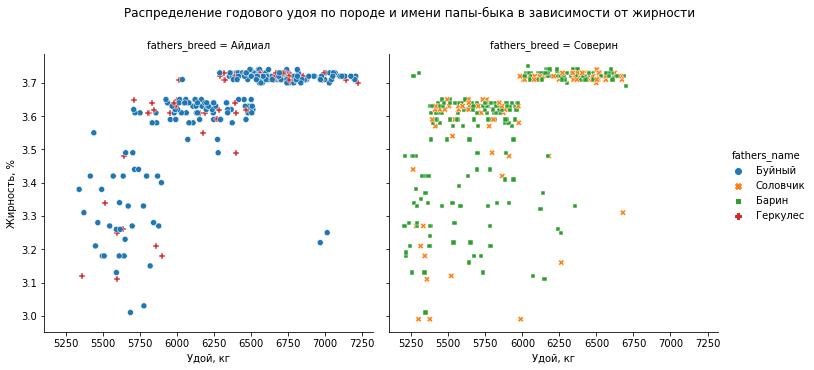

In [109]:
scatter = sns.relplot(data = df_main.merge(df_dad, how='right', on='id'),x ='milk_yield_kg', \
           y ='fat_%', col='fathers_breed', hue = 'fathers_name', style = 'fathers_name', kind='scatter')
scatter.fig.subplots_adjust(top=0.85)
scatter.fig.suptitle('Распределение годового удоя по породе и имени папы-быка в зависимости от жирности', size=12)
scatter.set_axis_labels('Удой, кг', 'Жирность, %')

plt.show()

Опять же, от конкретного быка не распределение не зависит: на распределение влияет порода быка.

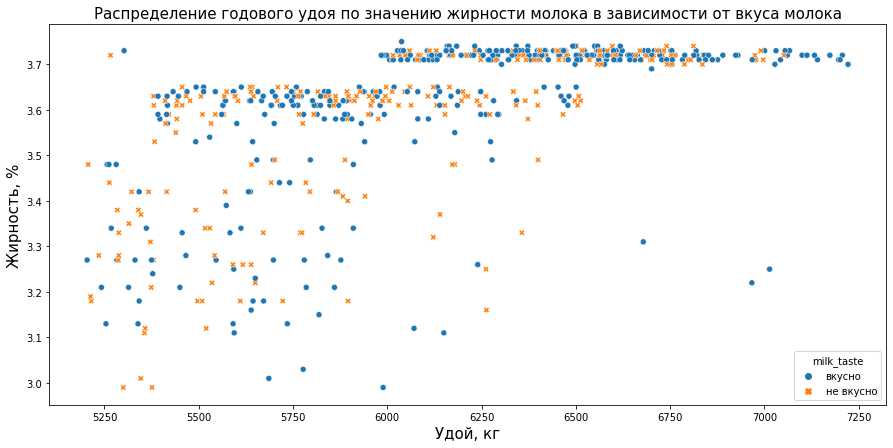

In [110]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='fat_%', hue = 'milk_taste', style='milk_taste', data = df_main)
plt.ylabel('Жирность, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению жирности молока в зависимости от вкуса молока', size=15)
plt.show()

При высоком проценте жирности преобладает вкусное молоко.

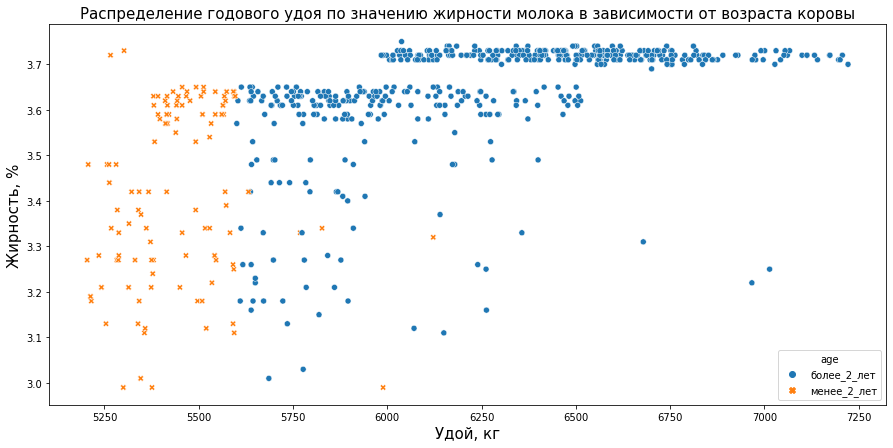

In [111]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='fat_%', hue = 'age', style='age', data = df_main)
plt.ylabel('Жирность, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по значению жирности молока в зависимости от возраста коровы', size=15)
plt.show()

Вновь при группировке данных по возрасту видна четкая граница между коровами возрастом менее двух лет и более двух лет. На данный момент поголовье дает чаще всего дает молоко жирностью от 3.6% до чуть больше 3.7%. Большее значение удоя преобладает у молока с большим процентом жирности.

#### *5. Удой и процент протеина в молоке*

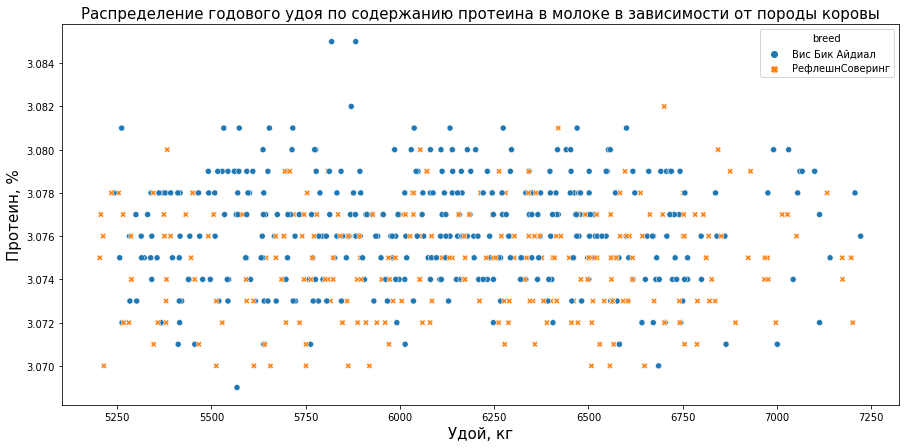

In [112]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='protein_%', hue = 'breed', style='breed', data = df_main)
plt.ylabel('Протеин, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию протеина в молоке в зависимости от породы коровы', size=15)
plt.show()

На графике выше видно, что взаимосвязь между удоем и содержанием протеина отсутствует или не является линейной. При этом видно, что молоко у коров породы Вис Бик Айдиал содержит чуть больше протеина.

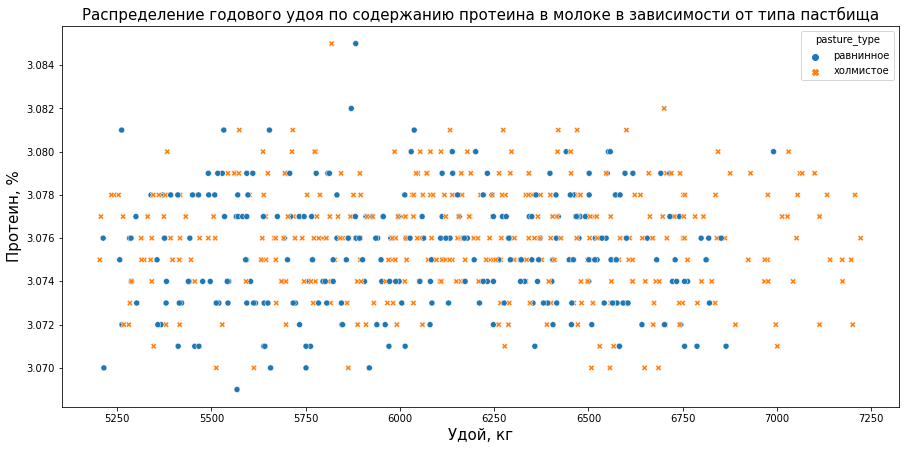

In [113]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='protein_%', hue = 'pasture_type', style='pasture_type', data = df_main)
plt.ylabel('Протеин, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию протеина в молоке в зависимости от типа пастбища', size=15)
plt.show()

Взаимосвязь удоя с протеином не меняется в зависимости от типа пастбищ. Коровы при любом содержании протеина в молоке и с удоем больше 7000 кг/год паслись на холмистых пастбищах.

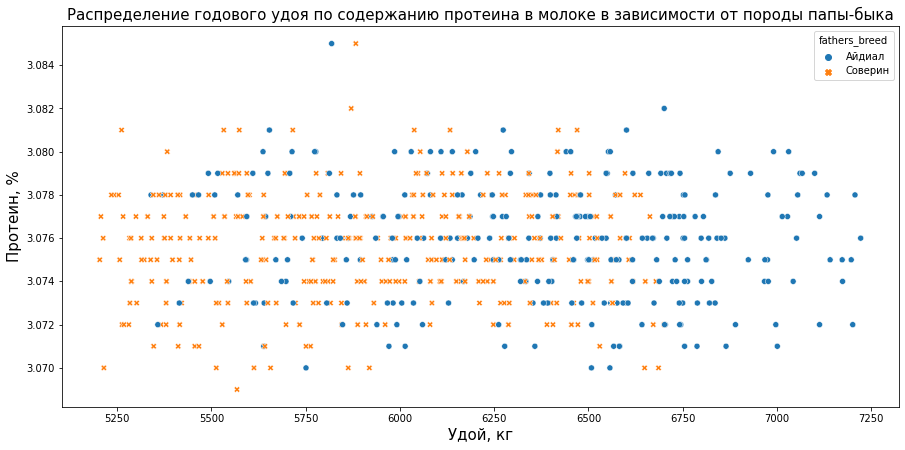

In [114]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='protein_%', hue = 'fathers_breed', style='fathers_breed', data = df_main)
plt.ylabel('Протеин, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию протеина в молоке в зависимости от породы папы-быка', size=15)
plt.show()

Коровы, рожденные от породы Айдиал, вне зависимости от содержания протеина в молоко, демонстрируют более высокие значения удоя.

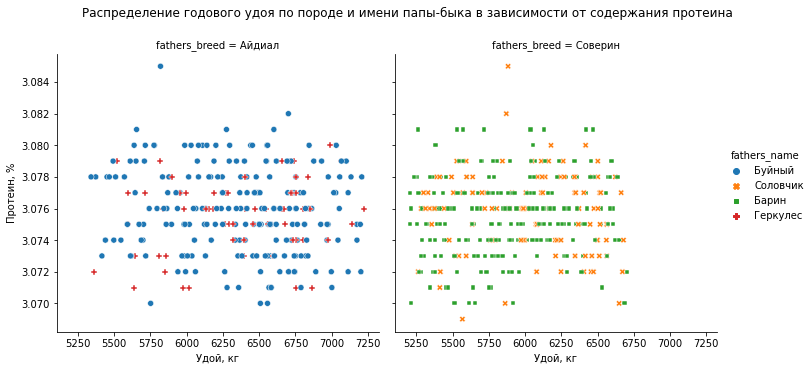

In [115]:
scatter = sns.relplot(data = df_main.merge(df_dad, how='right', on='id'),x ='milk_yield_kg', \
           y ='protein_%', col='fathers_breed', hue = 'fathers_name', style = 'fathers_name', kind='scatter')
scatter.fig.subplots_adjust(top=0.85)
scatter.fig.suptitle('Распределение годового удоя по породе и имени папы-быка в зависимости от содержания протеина', size=12)
scatter.set_axis_labels('Удой, кг', 'Протеин, %')

plt.show()

Есть единичные выбросы по содержанию протеина как в данных по породе Айдиал (Буйный), так и в данных по породе Соверин (Соловчик). В целом распределение по породе Айдиал более "вытянутое", с разбросом в удое от 5250 до 7250. Распределение по породе Соверин более "сжатое", с разбросом в удое от 5250 до 6750.

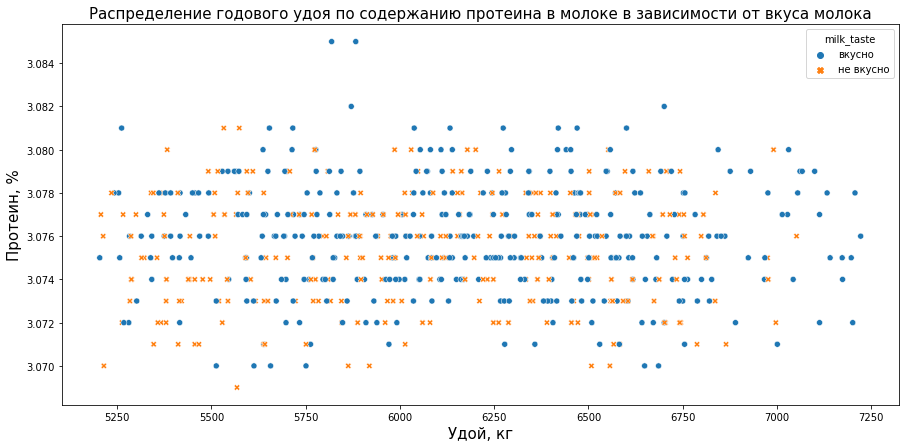

In [116]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='protein_%', hue = 'milk_taste', style='milk_taste', data = df_main)
plt.ylabel('Протеин, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию протеина в молоке в зависимости от вкуса молока', size=15)
plt.show()

Не зависимо от значения удоя и содержания протеина молоко может оказаться как вкусным, так и не вкусным.

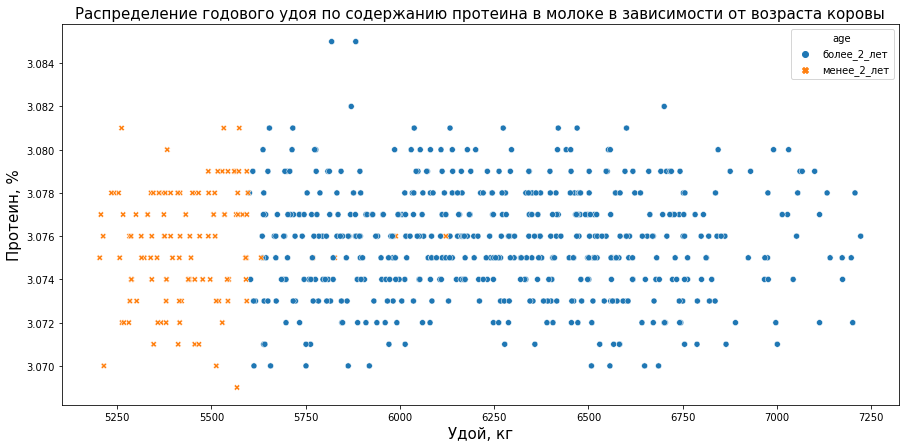

In [117]:
plt.figure(figsize=(15,7))
sns.scatterplot(x ='milk_yield_kg', y ='protein_%', hue = 'age', style='age', data = df_main)
plt.ylabel('Протеин, %', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение годового удоя по содержанию протеина в молоке в зависимости от возраста коровы', size=15)
plt.show()

Содержание протеина в молоке как коров младше 2 лет, так и коров больше двух лет может быть разным и не зависит от их возраста. При этом удой у коров старше 2 лет больше.

**Выводы:**


Таким образом, коэффициенты корреляции для целевого признака с входными признаками: 

**1. Умеренная (0.3 - 0.5)** корреляция наблюдается c признаками:
- сырой протеин в корме (crude_protein_g): 0.46

**2. Заметная (0.5 - 0.7)** корреляция наблюдается с признаками:
- СПО (sugar_protein_ratio): 0.66
- порода папы коровы (fathers_breed): 0.52

**3. Высокая (0.7 - 0.9)** корреляция наблюдается с признаками:
- ЭКЕ (eneergy_feed_unit): 0.72
- жирность (fat_%): 0.71
- возраст коровы (age): 1.0

**3. Мультиколлиниарность** между признаками не наблюдается (между входными признаками нет коэффициента корреляции выше 0.9).

**4. Нелинейные взаимосвязи** с целевым признаков выявлены у признаков жирность, содержание протеина, СПО. Необходимо ввести в модель дополнительные признаки, чтобы это учеть (например, СПО^2).


## Обучение модели линейной регрессии
<a id="regress"></a>

### Подготовка данных и обучение первой модели линейной регрессии

Для начала, необходимо отобрать входные признаки, которые будут описывать влияние на целевой в модели.

Целевым признаком является `Удой, кг (milk_yield_kg)`.

С учетом проведенного анализа в предыдущем блоке, в качестве входных признаков можно выбрать следующие:
- `ЭКЕ (energy_feed-unit)`: диаграммы рассеяния и коэффициент корреляции свидетельствуют о выраженной линейной связи.
- `СПО (sugar_protein_ratio)`: высокий коэффициент корреляции с целевым признаком; диаграммы рассеяния свидетельствуют о нелинейной связи с целевым признаком.
- `порода папы коровы (fathers_breed)`: основываясь на результатах анализа, порода папы коровы может влиять на объемы удоя.
- `возраст коровы (age)`: как показал анализ, возраст коровы значительно может влиять на объем удоя (четкое разделение на графиках).
- `тип пастбища (pasture_type)`: распределения по типу пастбищ немного отличались друг от другого.

Исходя из сказанного выше, отберем нужные нам данные:

In [118]:
df_lr_1 = (df_main
           .set_index('id')
           .drop(['breed','fat_%', 'protein_%','milk_taste'], axis=1))

X = df_lr_1.drop('milk_yield_kg', axis=1)
y = df_lr_1['milk_yield_kg']

In [119]:
categorial_col_names = ['pasture_type', 'fathers_breed', 'age']
num_col_names = ['energy_feed_unit','crude_protein_g', 'sugar_protein_ratio']

Теперь разделим данные на тренировочную и тестовую выборки.

In [120]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = RANDOM_STATE)

# проверка получившихся выборок
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(471, 6)
(157, 6)
(471,)
(157,)


Прежде чем обучать модель, необходимо закодировать категориальные переменные с помощью OneHotEncoder. В параметрах метода укажем параметр `drop='first'`, чтобы обработать дамми-ловушки.

In [121]:
encoder = OneHotEncoder(drop='first', sparse=False)

X_train_ohe = encoder.fit_transform(X_train[categorial_col_names])
X_test_ohe = encoder.transform(X_test[categorial_col_names])

encoder_col = encoder.get_feature_names() 

df_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col)
df_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col)

df_train_ohe.head()

,x0_холмистое,x1_Соверин,x2_менее_2_лет
0,1.0,1.0,0.0
1,1.0,1.0,1.0
2,0.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0


Теперь категориальные переменные закодированы в виде чисел, что позволит в дальнейшем их использование при обучении модели.

Далее нужно масштабировать количественные признаки, так как у каждого из них совершенно разные единицы измерения. Для масштабирования будем использовать стандартизацию `StandardScaler`.

In [122]:
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train[num_col_names])
X_test_scaler = scaler.transform(X_test[num_col_names])

df_train_scaler = pd.DataFrame(X_train_scaler, columns=num_col_names)
df_test_scaler = pd.DataFrame(X_test_scaler, columns=num_col_names)

Получились четыре новых дата фрейма: два относятся к тестовой выборке и два к тренировочной. Объединим обработанные данные по входным признакам, чтобы по каждой выборке был один датафрейм.

In [123]:
X_train_1 = pd.concat([df_train_ohe, df_train_scaler], axis=1)
X_test_1 = pd.concat([df_test_ohe, df_test_scaler], axis=1)

X_train_1.head()

,x0_холмистое,x1_Соверин,x2_менее_2_лет,energy_feed_unit,crude_protein_g,sugar_protein_ratio
0,1.0,1.0,0.0,1.502378,1.079523,0.837130
1,1.0,1.0,1.0,-1.557270,-0.196920,-0.703660
2,0.0,0.0,0.0,0.125537,-1.386085,-1.011818
3,1.0,0.0,0.0,-0.103937,0.752230,0.837130
4,0.0,0.0,0.0,-1.098323,0.828598,-0.703660


Данные подготовлены, теперь можно преступить к обучению модели линейной регрессии.

In [124]:
model_lr  = LinearRegression()
model_lr.fit(X_train_1, y_train)
predictions = model_lr.predict(X_test_1)

Чтобы оценить качество модели, посмотрим на одну из метрик - R^2, также проанализируем графики остататков.

In [125]:
r2 = r2_score(y_test, predictions)
print("R2 LinearRegression_1 =", r2)

R2 LinearRegression_1 = 0.8013463446105905


Значение коэффициента дететрминации у данной модели равен 0.8 - 80% предсказаний модели ближе к истине, чем средние значение целевого признака. 

Теперь проанализируем с помощью графиков остатки.

In [126]:
residuals = y_test - predictions

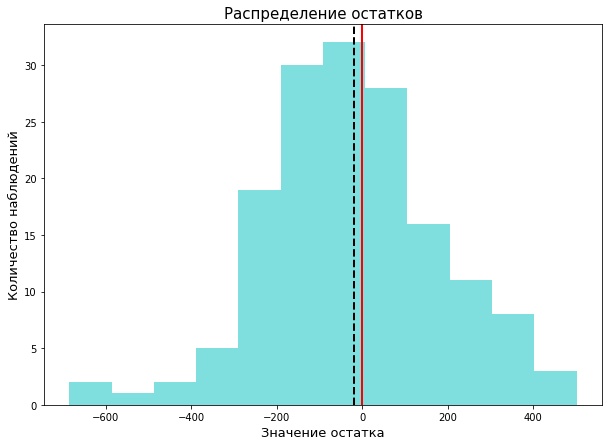

In [127]:
plt.figure(figsize=(10,7))
plt.hist(residuals, bins=12, color='c', alpha=0.5)
plt.axvline(residuals.mean(), color='k', linestyle='dashed', linewidth=2)
plt.axvline(0, color='r', linewidth=2)
plt.xlabel('Значение остатка', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение остатков', size=15)
plt.show()

Видно смещение среднего значения остатков влево - модель часто дает предсказания бОльшего значения, чем истинные. Чтобы убрать такое смещение в остатках необходимо добавить в модель новый признак.

Теперь построим диграмму рассеяния, чтобы посмотреть как распределяются предсказанные значения и остатки.

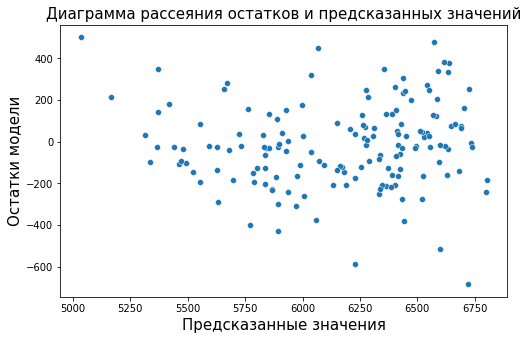

In [128]:
plt.figure(figsize=(8,5))
sns.scatterplot(x =predictions, y =residuals)
plt.ylabel('Остатки модели', size=15)
plt.xlabel('Предсказанные значения', size=15)
plt.title('Диаграмма рассеяния остатков и предсказанных значений', size=15)
plt.show()

В диаграмме рассеяния прослеживается дугообразная форма - возможно один из входящих признаков связан с целевым нелинейно. 

С учетом всего вышесказанного необходимо провести некоторые корректировки, чтобы модель стала более точной и надежной.

### Дополнительная обработка данных и подготовка второй модели регрессии

В параграфе 4 на графиках было видно, что СПО и Удой связаны нелинейно. Посмотрим еще раз на их диаграмму рассеяния.

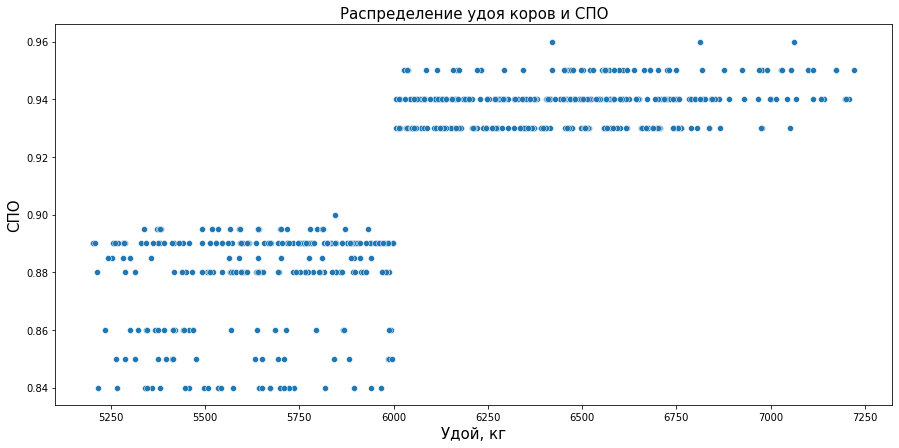

In [129]:
plt.figure(figsize=(15,7))
sns.scatterplot(x = y, y =X['sugar_protein_ratio'])
plt.ylabel('СПО', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение удоя коров и СПО', size=15)
plt.show()

Видна группировка данных по СПО: часть данных находится в диапазоне до 0.9, а часть данных в диапазоне больше 0.9. Преобразуем СПО в бинарный признак: значения выше 0.9 обозначим 1, а остальные - 0.

Теперь СПО - категориальная переменная.

In [130]:
X.loc[X['sugar_protein_ratio']>0.9, 'sugar_protein_ratio'] = 1
X.loc[X['sugar_protein_ratio']<=0.9, 'sugar_protein_ratio'] = 0

X['sugar_protein_ratio'].unique()

array([0., 1.])

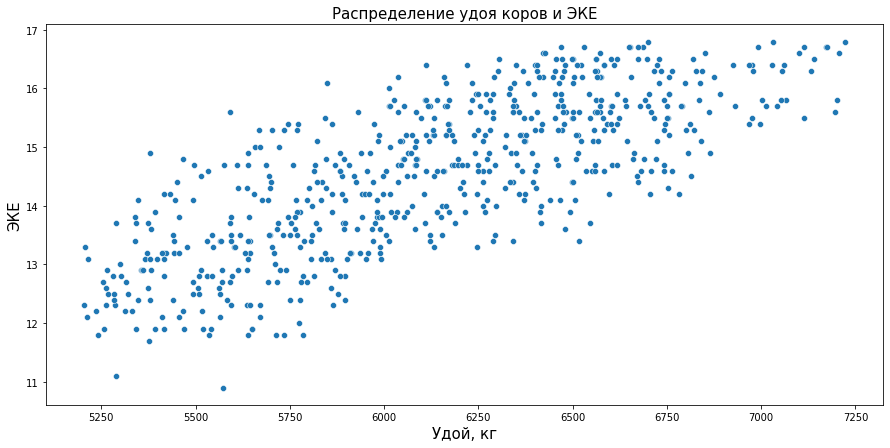

In [131]:
plt.figure(figsize=(15,7))
sns.scatterplot(x = y, y =X['energy_feed_unit'])
plt.ylabel('ЭКЕ', size=15)
plt.xlabel('Удой, кг', size=15)
plt.title('Распределение удоя коров и ЭКЕ', size=15)
plt.show()

Удой также нелинейно связан с ЭКЕ. Чтобы устранить эту нелинейность добавим новый признак - ЭКЕ в квадрате.

In [132]:
X['energy_feed_unit_sq'] = X['energy_feed_unit']**2
X['energy_feed_unit_sq']

id
1      201.64
2      163.84
3      196.00
4      153.76
5      163.84
        ...  
625    237.16
626    166.41
627    207.36
628    190.44
629    262.44
Name: energy_feed_unit_sq, Length: 628, dtype: float64

Обновив данные, снова проведем обучение модели.

In [133]:
categorial_col_names = ['pasture_type', 'fathers_breed', 'age']
num_col_names = ['crude_protein_g', 'energy_feed_unit_sq']

Теперь разделим данные на тренировочную и тестовую выборки.

In [134]:
RANDOM_STATE = 42
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, random_state = RANDOM_STATE)

# проверка получившихся выборок
print(X_train_2.shape)
print(X_test_2.shape)
print(y_train_2.shape)
print(y_test_2.shape)

(471, 7)
(157, 7)
(471,)
(157,)


In [135]:
# Кодировка категориальных переменных
encoder_2 = OneHotEncoder(drop='first', sparse=False)

X_train_ohe_2 = encoder_2.fit_transform(X_train_2[categorial_col_names])
X_test_ohe_2 = encoder_2.transform(X_test_2[categorial_col_names])

encoder_col_2 = encoder_2.get_feature_names() 

df_train_ohe_2 = pd.DataFrame(X_train_ohe_2, columns=encoder_col_2)
df_test_ohe_2 = pd.DataFrame(X_test_ohe_2, columns=encoder_col_2)

df_train_ohe_2

,x0_холмистое,x1_Соверин,x2_менее_2_лет
0,1.0,1.0,0.0
1,1.0,1.0,1.0
2,0.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0
...,...,...,...
466,1.0,1.0,0.0
467,0.0,0.0,0.0
468,0.0,0.0,0.0
469,0.0,0.0,0.0


In [136]:
# Масштабирование методом стандартизации
scaler_2 = StandardScaler()

X_train_scaler_2 = scaler_2.fit_transform(X_train_2[num_col_names])
X_test_scaler_2 = scaler_2.transform(X_test_2[num_col_names])

df_train_scaler_2 = pd.DataFrame(X_train_scaler_2, columns=num_col_names)
df_test_scaler_2 = pd.DataFrame(X_test_scaler_2, columns=num_col_names)

df_train_scaler_2

,crude_protein_g,energy_feed_unit_sq
0,1.079523,1.577968
1,-0.196920,-1.511438
2,-1.386085,0.082269
3,0.752230,-0.150235
4,0.828598,-1.102358
...,...,...
466,1.565008,-0.674102
467,-0.998788,0.239936
468,-0.818777,-0.890627
469,0.130373,-1.102358


In [137]:
# Собираем все обработанные параметры вместе
X_2_train = pd.concat([df_train_ohe_2, df_train_scaler_2], axis=1)
X_2_test = pd.concat([df_test_ohe_2, df_test_scaler_2], axis=1)

# Добавим столбец бинарный СПО 
X_2_train = pd.concat([X_2_train, X_train_2['sugar_protein_ratio'].reset_index(drop=True)], axis=1)
X_2_test = pd.concat([X_2_test, X_test_2['sugar_protein_ratio'].reset_index(drop=True)], axis=1)

X_2_train

,x0_холмистое,x1_Соверин,x2_менее_2_лет,crude_protein_g,energy_feed_unit_sq,sugar_protein_ratio
0,1.0,1.0,0.0,1.079523,1.577968,1.0
1,1.0,1.0,1.0,-0.196920,-1.511438,0.0
2,0.0,0.0,0.0,-1.386085,0.082269,0.0
3,1.0,0.0,0.0,0.752230,-0.150235,1.0
4,0.0,0.0,0.0,0.828598,-1.102358,0.0
...,...,...,...,...,...,...
466,1.0,1.0,0.0,1.565008,-0.674102,0.0
467,0.0,0.0,0.0,-0.998788,0.239936,1.0
468,0.0,0.0,0.0,-0.818777,-0.890627,0.0
469,0.0,0.0,0.0,0.130373,-1.102358,0.0


In [138]:
# обучаем модель
model_lr_2  = LinearRegression()
model_lr_2.fit(X_2_train, y_train_2)
predictions_2 = model_lr_2.predict(X_2_test)

In [139]:
# оцениваем коэффициент детерминации
r2_2 = r2_score(y_test_2, predictions_2)
print("R2 LinearRegression_2 =", r2_2)

R2 LinearRegression_2 = 0.8237949958564095


Коэффициент детерминации у второй модели получился четь больше - 82,4% (у первой - 80%).

In [140]:
residuals_2 = y_test_2 - predictions_2

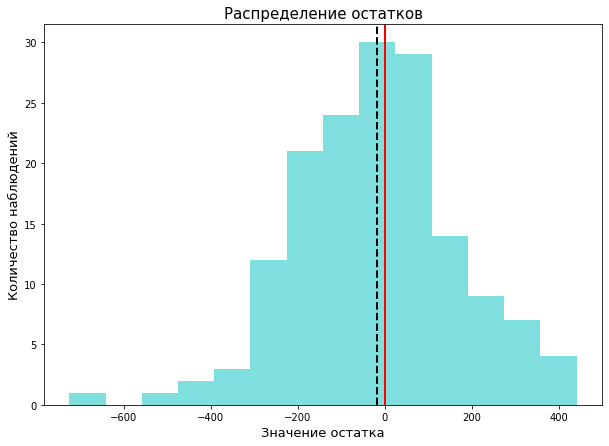

In [141]:
#Анализ остатков
plt.figure(figsize=(10,7))
plt.hist(residuals_2, bins=14, color='c', alpha=0.5)
plt.axvline(residuals_2.mean(), color='k', linestyle='dashed', linewidth=2)
plt.axvline(0, color='r', linewidth=2)
plt.xlabel('Значение остатка', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение остатков', size=15)
plt.show()

В распределении остатков появился выброс, среднее значение также смещено влево.

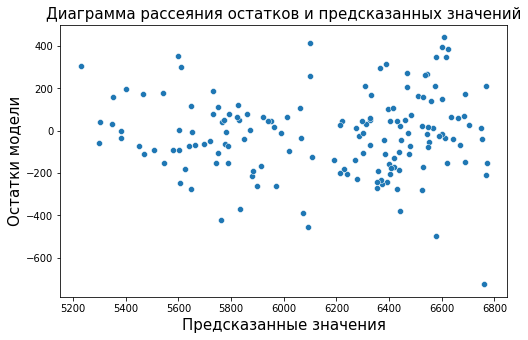

In [142]:
plt.figure(figsize=(8,5))
sns.scatterplot(x =predictions_2, y =residuals_2)
plt.ylabel('Остатки модели', size=15)
plt.xlabel('Предсказанные значения', size=15)
plt.title('Диаграмма рассеяния остатков и предсказанных значений', size=15)
plt.show()

### Построение третьей модели

Объединим данные и добавим признак "имя папы коровы".

In [143]:
X_merged = (X
            .merge(df_dad.set_index('id'), how='left', on='id')
            .drop('fathers_breed', axis=1))
X_merged.head()

,energy_feed_unit,crude_protein_g,sugar_protein_ratio,pasture_type,age,energy_feed_unit_sq,fathers_name
id,,,,,,,
1,14.2,1743,0.0,равнинное,более_2_лет,201.64,Буйный
2,12.8,2138,0.0,равнинное,менее_2_лет,163.84,Соловчик
3,14.0,1854,0.0,холмистое,более_2_лет,196.00,Барин
4,12.4,2012,0.0,холмистое,более_2_лет,153.76,Буйный
5,12.8,1675,0.0,равнинное,менее_2_лет,163.84,Барин


Далее обучим модель так же, как и в блоках выше.

In [144]:
# наименование категориальных и количественных признаков
categorial_col_names = ['pasture_type', 'age', 'fathers_name']
num_col_names = ['crude_protein_g', 'energy_feed_unit_sq']

In [145]:
# разделим выборку на тренировочную и тестовую
RANDOM_STATE = 42
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_merged, y, random_state = RANDOM_STATE)

# проверка получившихся выборок
print(X_train_3.shape)
print(X_test_3.shape)
print(y_train_3.shape)
print(y_test_3.shape)

(471, 7)
(157, 7)
(471,)
(157,)


In [146]:
# Кодировка категориальных переменных
encoder_3 = OneHotEncoder(drop='first', sparse=False)

X_train_ohe_3 = encoder_3.fit_transform(X_train_3[categorial_col_names])
X_test_ohe_3 = encoder_3.transform(X_test_3[categorial_col_names])

encoder_col_3 = encoder_3.get_feature_names() 

df_train_ohe_3 = pd.DataFrame(X_train_ohe_3, columns=encoder_col_3)
df_test_ohe_3 = pd.DataFrame(X_test_ohe_3, columns=encoder_col_3)

df_train_ohe_3

,x0_холмистое,x1_менее_2_лет,x2_Буйный,x2_Геркулес,x2_Соловчик
0,1.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
466,1.0,0.0,0.0,0.0,0.0
467,0.0,0.0,0.0,1.0,0.0
468,0.0,0.0,0.0,1.0,0.0
469,0.0,0.0,1.0,0.0,0.0


In [147]:
# Масштабирование методом стандартизации
scaler_3 = StandardScaler()

X_train_scaler_3 = scaler_3.fit_transform(X_train_3[num_col_names])
X_test_scaler_3 = scaler_3.transform(X_test_3[num_col_names])

df_train_scaler_3 = pd.DataFrame(X_train_scaler_3, columns=num_col_names)
df_test_scaler_3 = pd.DataFrame(X_test_scaler_3, columns=num_col_names)

df_train_scaler_3

,crude_protein_g,energy_feed_unit_sq
0,1.079523,1.577968
1,-0.196920,-1.511438
2,-1.386085,0.082269
3,0.752230,-0.150235
4,0.828598,-1.102358
...,...,...
466,1.565008,-0.674102
467,-0.998788,0.239936
468,-0.818777,-0.890627
469,0.130373,-1.102358


In [148]:
# Собираем все обработанные параметры вместе
X_3_train = pd.concat([df_train_ohe_3, df_train_scaler_3], axis=1)
X_3_test = pd.concat([df_test_ohe_3, df_test_scaler_3], axis=1)

# Добавим столбец бинарный СПО 
X_3_train = pd.concat([X_3_train, X_train_3['sugar_protein_ratio'].reset_index(drop=True)], axis=1)
X_3_test = pd.concat([X_3_test, X_test_3['sugar_protein_ratio'].reset_index(drop=True)], axis=1)

X_3_train

,x0_холмистое,x1_менее_2_лет,x2_Буйный,x2_Геркулес,x2_Соловчик,crude_protein_g,energy_feed_unit_sq,sugar_protein_ratio
0,1.0,0.0,0.0,0.0,1.0,1.079523,1.577968,1.0
1,1.0,1.0,0.0,0.0,0.0,-0.196920,-1.511438,0.0
2,0.0,0.0,1.0,0.0,0.0,-1.386085,0.082269,0.0
3,1.0,0.0,1.0,0.0,0.0,0.752230,-0.150235,1.0
4,0.0,0.0,0.0,1.0,0.0,0.828598,-1.102358,0.0
...,...,...,...,...,...,...,...,...
466,1.0,0.0,0.0,0.0,0.0,1.565008,-0.674102,0.0
467,0.0,0.0,0.0,1.0,0.0,-0.998788,0.239936,1.0
468,0.0,0.0,0.0,1.0,0.0,-0.818777,-0.890627,0.0
469,0.0,0.0,1.0,0.0,0.0,0.130373,-1.102358,0.0


In [149]:
# обучаем модель
model_lr_3  = LinearRegression()
model_lr_3.fit(X_3_train, y_train_3)
predictions_3 = model_lr_3.predict(X_3_test)

In [150]:
# оцениваем коэффициент детерминации
r2_3 = r2_score(y_test_3, predictions_3)
print("R2 LinearRegression_3 =", r2_3)

R2 LinearRegression_3 = 0.8239420345635141


In [151]:
# остатки
residuals_3 = y_test_3 - predictions_3

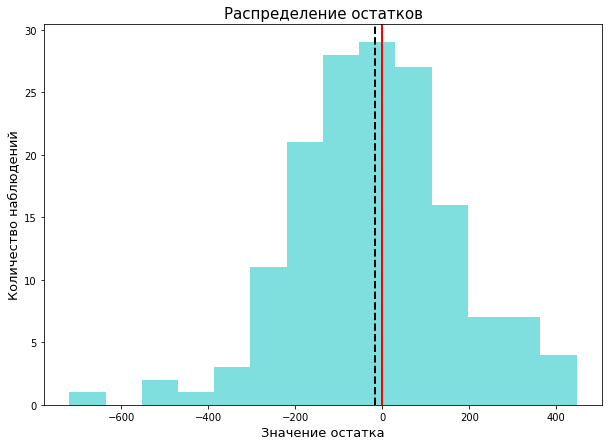

In [152]:
#Анализ остатков
plt.figure(figsize=(10,7))
plt.hist(residuals_3, bins=14, color='c', alpha=0.5)
plt.axvline(residuals_3.mean(), color='k', linestyle='dashed', linewidth=2)
plt.axvline(0, color='r', linewidth=2)
plt.xlabel('Значение остатка', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение остатков', size=15)
plt.show()

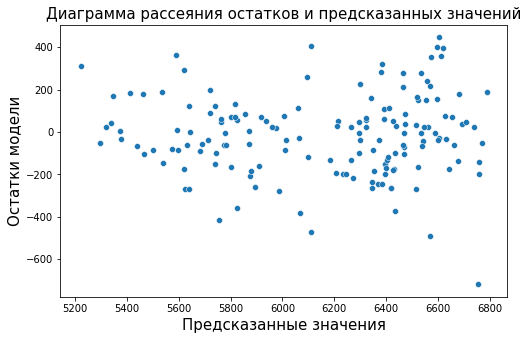

In [153]:
plt.figure(figsize=(8,5))
sns.scatterplot(x =predictions_3, y =residuals_3)
plt.ylabel('Остатки модели', size=15)
plt.xlabel('Предсказанные значения', size=15)
plt.title('Диаграмма рассеяния остатков и предсказанных значений', size=15)
plt.show()

Еще раз посмотрим на коэффициенты детерминации у трех моделей. 

In [154]:
print("R2 LinearRegression_1 =", r2)
print("R2 LinearRegression_2 =", r2_2)
print("R2 LinearRegression_3 =", r2_3)

R2 LinearRegression_1 = 0.8013463446105905
R2 LinearRegression_2 = 0.8237949958564095
R2 LinearRegression_3 = 0.8239420345635141


Наибольшее значение коэффициента детерминации демонстрирует модель 3. Однако, на диаграмме рассеяния остатков модели 3 видно непостоянство остатков. Исходя из текущих данных для анализа моделей, наиболее привлекательной выглядит модель 2.

Для более точной оценки качества моделей посмотрим на хначения их метрик.

### Оценка качества моделей по метрикам MSE, MAE, RMSE

#### MSE

Оценим качество трех моделей по среднеквадратичной ошибке.

In [155]:
mse_1 = mean_squared_error(y_test, predictions)
mse_2 = mean_squared_error(y_test_2, predictions_2)
mse_3 = mean_squared_error(y_test_3, predictions_3)

In [156]:
print('Значение среднеквадратичной ошибки модели 1:', mse_1)
print('Значение среднеквадратичной ошибки модели 2:', mse_2)
print('Значение среднеквадратичной ошибки модели 3:', mse_3)

Значение среднеквадратичной ошибки модели 1: 40438.924307458714
Значение среднеквадратичной ошибки модели 2: 35869.165413494724
Значение среднеквадратичной ошибки модели 3: 35839.233484302604


Чем ниже значение данной метрики, тем лучше качество модели. 

Таким образом, модель 1 предсказывает хуже, чем модели 2 и 3. В свою очередь значение среднеквадратичной ошибки у моделей 2 и 3 практически одинаковые.

#### MAE

Оценим качество моделей с помощью оценки средней абсолютной ошибки.

In [157]:
mae_1 = mean_absolute_error(y_test, predictions)
mae_2 = mean_absolute_error(y_test_2, predictions_2)
mae_3 = mean_absolute_error(y_test_3, predictions_3)

In [158]:
print('Значение средней абсолютной ошибки модели 1:', mae_1)
print('Значение средней абсолютной ошибки модели 2:', mae_2)
print('Значение средней абсолютной ошибки модели 3:', mae_3)

Значение средней абсолютной ошибки модели 1: 155.38517052604985
Значение средней абсолютной ошибки модели 2: 144.9115116248853
Значение средней абсолютной ошибки модели 3: 145.3202127673875


Чем меньше средняя абсолютная ошибка, тем лучше модель предсказывает целевой признак. 

Таким образом, по данной метрике наилучшей моделью является модель 2.

#### RMSE

Оценим качество моделей по квадратному корню среднеквадратичной ошибки. Это даст нам представление о том, на сколько в среднем ошибается модель в предсказании удоя.

In [159]:
rmse_1 = mean_squared_error(y_test, predictions, squared=False)
rmse_2 = mean_squared_error(y_test_2, predictions_2, squared=False)
rmse_3 = mean_squared_error(y_test_3, predictions_3, squared=False)

In [160]:
print('Значение квадратного корня среднеквадратичной ошибки модели 1:', rmse_1)
print('Значение квадратного корня среднеквадратичной ошибки модели 2:', rmse_2)
print('Значение квадратного корня среднеквадратичной ошибки модели 3:', rmse_3)

Значение квадратного корня среднеквадратичной ошибки модели 1: 201.09431694470808
Значение квадратного корня среднеквадратичной ошибки модели 2: 189.39156637372935
Значение квадратного корня среднеквадратичной ошибки модели 3: 189.31252859835402


Получилось, что первая модель ошибается в среднем на 201.1 кг при прогнозировании удоя. 

Второя модель ошибается в среднем на 189.4 кг при прогнозировании удоя.

Третья модель ошибается в среднем на 189.3 кг при прогнозировании удоя. 

Таким образом, с учетом всех метрик, предлагается выбрать модель 2.

Доверительный интервал модели 2:

In [161]:
errors = residuals_2
quantiles=(0.025, 0.975)

lower_quantile = np.quantile(errors, quantiles[0])
upper_quantile = np.quantile(errors, quantiles[1])

print(f"Доверительный интервал прогноза: [{lower_quantile}, {upper_quantile}]")

Доверительный интервал прогноза: [-390.3964384545704, 358.0522652162017]


Получается, что в 95% случаев ошибка прогноза не превышает 358.05 кг.

<br/>
<div class="alert alert-info">
👍
</div>

### Прогноз с помощью модели

Подготовим данные по коровам к покупке для прогноза удоя.

In [162]:
df_buy_final = df_buy[['pasture_type', 'fathers_breed', 'age']]

energy = round(df_main.loc[:,'energy_feed_unit'].mean()*1.05,1)
protein = round(df_main.loc[:,'crude_protein_g'].mean()*1.05)
ratio = round(df_main.loc[:,'sugar_protein_ratio'].mean()*1.05, 2)

df_buy_final.loc[:,'energy_feed_unit_sq'] = energy**2
df_buy_final.loc[:,'crude_protein_g'] = protein
df_buy_final.loc[:,'sugar_protein_ratio'] = ratio

df_buy_final.head()

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


,pasture_type,fathers_breed,age,energy_feed_unit_sq,crude_protein_g,sugar_protein_ratio
0,холмистое,Айдиал,более_2_лет,234.09,2020,0.96
1,равнинное,Соверин,менее_2_лет,234.09,2020,0.96
2,равнинное,Соверин,более_2_лет,234.09,2020,0.96
3,холмистое,Айдиал,более_2_лет,234.09,2020,0.96
4,равнинное,Айдиал,более_2_лет,234.09,2020,0.96


Сделаем переменную СПО категориальной.

In [163]:
df_buy_final.loc[df_buy_final['sugar_protein_ratio']>0.9, 'sugar_protein_ratio'] = 1
df_buy_final.loc[df_buy_final['sugar_protein_ratio']<=0.9, 'sugar_protein_ratio'] = 0

df_buy_final.head()

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


,pasture_type,fathers_breed,age,energy_feed_unit_sq,crude_protein_g,sugar_protein_ratio
0,холмистое,Айдиал,более_2_лет,234.09,2020,1.0
1,равнинное,Соверин,менее_2_лет,234.09,2020,1.0
2,равнинное,Соверин,более_2_лет,234.09,2020,1.0
3,холмистое,Айдиал,более_2_лет,234.09,2020,1.0
4,равнинное,Айдиал,более_2_лет,234.09,2020,1.0


In [164]:
# наименование категориальных и количественных признаков
categorial_col_names = ['pasture_type', 'fathers_breed', 'age']
num_col_names = ['crude_protein_g', 'energy_feed_unit_sq']

In [165]:
# Кодировка категориальных переменных
buy_ohe = encoder_2.transform(df_buy_final[categorial_col_names])

encoder_col = encoder_2.get_feature_names() 

df_ohe = pd.DataFrame(buy_ohe, columns=encoder_col)

df_ohe.head()

,x0_холмистое,x1_Соверин,x2_менее_2_лет
0,1.0,0.0,0.0
1,0.0,1.0,1.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0


In [166]:
# Масштабирование методом стандартизации
buy_scaler = scaler_2.transform(df_buy_final[num_col_names])

df_scaler = pd.DataFrame(buy_scaler, columns=num_col_names)

df_scaler.head()

,crude_protein_g,energy_feed_unit_sq
0,0.51767,0.56166
1,0.51767,0.56166
2,0.51767,0.56166
3,0.51767,0.56166
4,0.51767,0.56166


In [167]:
# Собираем все обработанные параметры вместе
df_buy_pred = pd.concat([df_ohe, df_scaler], axis=1)

# Добавим столбец бинарный СПО 
df_buy_pred = pd.concat([df_buy_pred, df_buy_final['sugar_protein_ratio']], axis=1)

df_buy_pred.head()

,x0_холмистое,x1_Соверин,x2_менее_2_лет,crude_protein_g,energy_feed_unit_sq,sugar_protein_ratio
0,1.0,0.0,0.0,0.51767,0.56166,1.0
1,0.0,1.0,1.0,0.51767,0.56166,1.0
2,0.0,1.0,0.0,0.51767,0.56166,1.0
3,1.0,0.0,0.0,0.51767,0.56166,1.0
4,0.0,0.0,0.0,0.51767,0.56166,1.0


Данные подготовлены, теперь можно делать прогноз по покупке.

In [168]:
predictions_final = model_lr_2.predict(df_buy_pred)

In [169]:
df_buy_final['milk_yield_kg'] = predictions_final
df_buy_final

,pasture_type,fathers_breed,age,energy_feed_unit_sq,crude_protein_g,sugar_protein_ratio,milk_yield_kg
0,холмистое,Айдиал,более_2_лет,234.09,2020,1.0,6592.507302
1,равнинное,Соверин,менее_2_лет,234.09,2020,1.0,6092.467482
2,равнинное,Соверин,более_2_лет,234.09,2020,1.0,6287.375029
3,холмистое,Айдиал,более_2_лет,234.09,2020,1.0,6592.507302
4,равнинное,Айдиал,более_2_лет,234.09,2020,1.0,6546.791627
5,равнинное,Соверин,менее_2_лет,234.09,2020,1.0,6092.467482
6,холмистое,Айдиал,более_2_лет,234.09,2020,1.0,6592.507302
7,равнинное,Соверин,более_2_лет,234.09,2020,1.0,6287.375029
8,равнинное,Соверин,более_2_лет,234.09,2020,1.0,6287.375029
9,холмистое,Айдиал,менее_2_лет,234.09,2020,1.0,6397.599755


**Вывод:**
- была проведена подготовка данных и обучение для трех моделей линейной регрессии.
- в первой модели регрессии в качестве входных признаков были отобраны pasture_type, fathers_breed, age, sugar_protein_ratio, energy_feed_unit, crude_protein_g. Данные признаки выбраны на основании анализа, проведенного в п.4
- во второй модели регрессии была учтена нелинейность взаимосвязи между целевым и некоторыми входными признаками: был добавлен новый признак energy_feed_unit_sq (ЭКЕ в квадрате), а также признак sugar_protein_ratio был преобразован в бинарный. 
- в третью модель был добавлен новый признак fathers_name.
- после обучения всех моделей, была проведена их оценка по трем метрикам: MSE, MAE, RMSE. На основании данных метрик, а также с учетом анализа остатков каждой из моделей, была выбрана модель номер 2.
- с помощью модели 2 был сделан прогноз удоя для коров из датасета к покупке. Значения удоя добавлены в общую таблицу. У всех коров значения удоя получились больше 6000 кг в год. Однако, при отборе нужно помнить, что модель немного заавышает прогнозы и нужно также учитывать доверительный интервал для модели 2.

Теперь спрогнозируем вкус молока с помощью модели логистической регрессии.

## Обучение модели логистической регрессии

### Подготовка данных, обучение и оценка с помощью метрик модели логистической регрессии

In [170]:
df_lg = (df_main
         .merge(df_dad, how='left', on='id')
         .set_index('id'))
df_lg.head()

,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,fathers_breed,fat_%,protein_%,milk_taste,age,fathers_name
id,,,,,,,,,,,,
1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный
2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик
3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин
4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный
5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин


Заменим значения в целевой переменной следующим образом: 1 - молоко вкусное, 0 - молоко не вкусное.

In [171]:
df_lg.loc[df_lg['milk_taste']=='вкусно', 'milk_taste'] = 1
df_lg.loc[df_lg['milk_taste']=='не вкусно', 'milk_taste'] = 0

In [172]:
df_lg['milk_taste'] = df_lg['milk_taste'].astype('float')

Разделим основной датафрейм на два: один будет содержать целевой признак `вкус молока`, другой - входные признаки.

In [173]:
X = df_lg.drop(['milk_taste'], axis = 1)
y = df_lg['milk_taste']

Определим категориальные и количественные переменные.

In [174]:
categorial_col_names = ['breed','pasture_type', 'fathers_breed', 'age', 'fathers_name']
num_col_names = ['energy_feed_unit','crude_protein_g', 'sugar_protein_ratio', 'fat_%', 'protein_%']

Разделим данные на тренировочную и тестовую выборки.

In [175]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = RANDOM_STATE)

# проверка получившихся выборок
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(471, 11)
(157, 11)
(471,)
(157,)


Закодируем категориальные переменные.

In [176]:
encoder = OneHotEncoder(drop='first', sparse=False)

X_train_ohe = encoder.fit_transform(X_train[categorial_col_names])
X_test_ohe = encoder.transform(X_test[categorial_col_names])

encoder_col = encoder.get_feature_names() 

df_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col)
df_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col)

df_train_ohe.head()

,x0_РефлешнСоверинг,x1_холмистое,x2_Соверин,x3_менее_2_лет,x4_Буйный,x4_Геркулес,x4_Соловчик
0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
1,1.0,1.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Масштабируем количественные данные с помощью стандартизации.

In [177]:
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train[num_col_names])
X_test_scaler = scaler.transform(X_test[num_col_names])

df_train_scaler = pd.DataFrame(X_train_scaler, columns=num_col_names)
df_test_scaler = pd.DataFrame(X_test_scaler, columns=num_col_names)

df_train_scaler.head()

,energy_feed_unit,crude_protein_g,sugar_protein_ratio,fat_%,protein_%
0,1.502378,1.079523,0.837130,0.562532,-0.679069
1,-1.557270,-0.196920,-0.703660,-1.601817,-1.452568
2,0.125537,-1.386085,-1.011818,-2.563750,1.254677
3,-0.103937,0.752230,0.837130,0.081565,1.254677
4,-1.098323,0.828598,-0.703660,0.201807,0.094429


Получились четыре новых дата фрейма: два относятся к тестовой выборке и два к тренировочной. Объединим обработанные данные по входным признакам, чтобы по каждой выборке был один датафрейм.

In [178]:
X_train_1 = pd.concat([df_train_ohe, df_train_scaler], axis=1)
X_test_1 = pd.concat([df_test_ohe, df_test_scaler], axis=1)

X_train_1.head()

,x0_РефлешнСоверинг,x1_холмистое,x2_Соверин,x3_менее_2_лет,x4_Буйный,x4_Геркулес,x4_Соловчик,energy_feed_unit,crude_protein_g,sugar_protein_ratio,fat_%,protein_%
0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.502378,1.079523,0.837130,0.562532,-0.679069
1,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-1.557270,-0.196920,-0.703660,-1.601817,-1.452568
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.125537,-1.386085,-1.011818,-2.563750,1.254677
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.103937,0.752230,0.837130,0.081565,1.254677
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.098323,0.828598,-0.703660,0.201807,0.094429


Данные подготовлены, теперь можно преступить к обучению модели линейной регрессии.

In [179]:
model_clf = LogisticRegression()
model_clf.fit(X_train_1, y_train)
predictions = model_clf.predict(X_test_1)

Теперь оценим качество полученной модели на тестовой выборке с помощью метрик accuracy, recall, precision.

### Метрики accuracy, precision, recall

In [180]:
acc = accuracy_score(y_test, predictions)
print(acc)

0.6178343949044586


Значение метрики accuracy не высокое - лишь в 62% случаев модель дает правильные ответы. Теперь оценим модель с помощью метрики recall.

In [181]:
recall = recall_score(y_test, predictions)
print('recall: ',round(recall ,3))

recall:  0.852


Модель предсказывает 85% объектов класса 1 верно. Теперь посмотрим на метрику precision.

In [182]:
precision = precision_score(y_test, predictions)
print('precision: ',round(precision,3))

precision:  0.615


Исходя из значения метрики выше, можно сказать, что модель часто выставляет класс 1 объектам типа 0.

Построим матрицу ошибок.

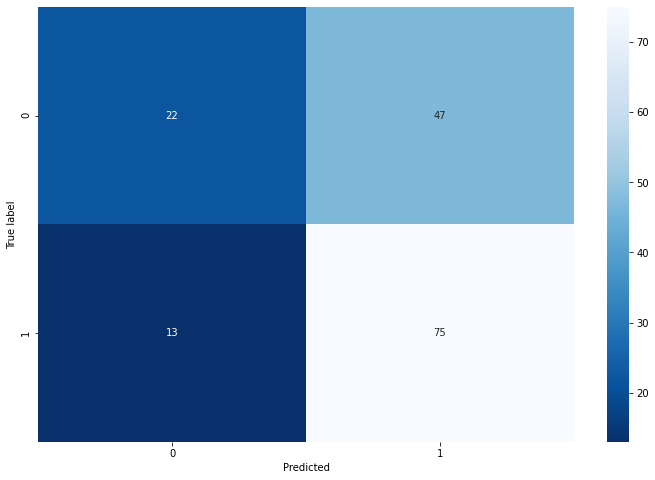

In [183]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted')
plt.show()

По матрице, как и по метрикам видно, что модель плохо обределяет объекты типа 0 - молоко не вкусное. 

Ошибкой первого рода в данном случае будет является маркировка не вкусного молока как вкусного. Ошибкой второго рода будет являться маркировка вкусного молока не вкусным. Поскольку для заказчика важно, чтобы молоко было вкусным, то более критичная ошибка это покупка коровы, которая дает не вкусное молоко, чем не покупка коровы, которая дает вкусное. Таким образом, исключение ошибки первого рода важнее, чем ошибки второго рода. Соответственно, необходимо поработать с порогом метрики percision.

In [184]:
y_proba = model_clf.predict_proba(X_test_1)[:,1]
data = pd.DataFrame(zip(y_test, y_proba),
columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)
data

,y_valid,y_proba
85,1.0,0.843348
110,1.0,0.827358
17,1.0,0.816556
66,1.0,0.809155
116,0.0,0.808795
...,...,...
23,1.0,0.330438
102,1.0,0.288746
46,0.0,0.285128
144,0.0,0.269131


In [185]:
thresholds = [round(i,2) for i in np.linspace(0.1,1,num = 8,endpoint=False)]
print(thresholds) 

[0.1, 0.21, 0.32, 0.44, 0.55, 0.66, 0.78, 0.89]


In [186]:
# создаём переменную, которая будет хранить список новых колонок
columns = []

# добавьте столбцы с новыми предсказаниями в таблицу
for i in thresholds:
    columns.append('y_pred_'+str(i))
    data['y_pred_'+str(i)] = data['y_proba'].apply(lambda x: 1 if x >= i else 0)

# выведем 5 случайных строк
print(data.sample(5))

    y_valid   y_proba  y_pred_0.1  y_pred_0.21  y_pred_0.32  y_pred_0.44  \
42      0.0  0.644388           1            1            1            1   
5       0.0  0.615323           1            1            1            1   
89      0.0  0.419594           1            1            1            0   
27      0.0  0.542529           1            1            1            1   
57      0.0  0.643506           1            1            1            1   

    y_pred_0.55  y_pred_0.66  y_pred_0.78  y_pred_0.89  
42            1            0            0            0  
5             1            0            0            0  
89            0            0            0            0  
27            0            0            0            0  
57            1            0            0            0  


In [187]:
for i in data.drop(['y_valid', 'y_proba'], axis=1).columns:
    TP = 0
    FP = 0
    for x in data.index:
        if data.loc[x,i]-data.loc[x,'y_valid'] == 0:
            TP += 1
        if data.loc[x,i]-data.loc[x,'y_valid'] == 1:
            FP += 1        
    print(f'Precision {i}:', round(TP/(TP+FP), 3))

Precision y_pred_0.1: 0.561
Precision y_pred_0.21: 0.561
Precision y_pred_0.32: 0.577
Precision y_pred_0.44: 0.651
Precision y_pred_0.55: 0.715
Precision y_pred_0.66: 0.836
Precision y_pred_0.78: 0.975
Precision y_pred_0.89: 1.0


При значении порога 0.78 значение метрики precision близко к максимальному.

In [188]:
# значение метрики recall при пороге 0.78
TP = 0
FN = 0
for x in data.index:
    if data.loc[x,'y_pred_0.78']-data.loc[x,'y_valid'] == 0:
        TP += 1
    if data.loc[x,'y_pred_0.78']-data.loc[x,'y_valid'] == -1:
        FN += 1        

print(f'Recall y_pred_0.78:', round(TP/(TP+FN), 3))

Recall y_pred_0.78: 0.503


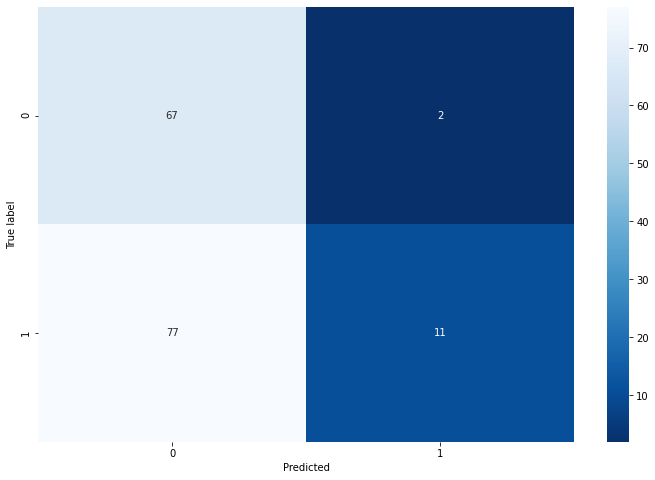

In [189]:
cm = confusion_matrix(data['y_valid'], data['y_pred_0.78'])

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted')
plt.show()

Ошибка первого рода была исключена - теперь коровы с не вкусным молоком не маркируются вкусным.

В дальнейших расчетах, с учетом того, что может быть 3-5 ложноположительных ошибок, для расчетов возьмем порог 0.78

### Предсказание модели

In [190]:
df_buy['sugar_protein_ratio'] = round(df_main['sugar_protein_ratio'].mean()*1.05, 2)
df_buy['crude_protein_g'] = round(df_main['crude_protein_g'].mean()*1.05)
df_buy['energy_feed_unit'] = round(df_main['energy_feed_unit'].mean()*1.05, 2)
df_buy.head()

,breed,pasture_type,fathers_breed,fathers_name,fat_%,protein_%,age,sugar_protein_ratio,crude_protein_g,energy_feed_unit
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.96,2020,15.28
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,0.96,2020,15.28
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,0.96,2020,15.28
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,0.96,2020,15.28
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,0.96,2020,15.28


In [191]:
df_buy['milk_yield_kg'] = predictions_final

In [192]:
df_buy.head()

,breed,pasture_type,fathers_breed,fathers_name,fat_%,protein_%,age,sugar_protein_ratio,crude_protein_g,energy_feed_unit,milk_yield_kg
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.96,2020,15.28,6592.507302
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,0.96,2020,15.28,6092.467482
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,0.96,2020,15.28,6287.375029
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,0.96,2020,15.28,6592.507302
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,0.96,2020,15.28,6546.791627


In [193]:
X_test_ohe = encoder.transform(df_buy[categorial_col_names])

encoder_col = encoder.get_feature_names() 

df_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col)

df_test_ohe.head()

,x0_РефлешнСоверинг,x1_холмистое,x2_Соверин,x3_менее_2_лет,x4_Буйный,x4_Геркулес,x4_Соловчик
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [194]:
X_test_scaler = scaler.transform(df_buy[num_col_names])

df_test_scaler = pd.DataFrame(X_test_scaler, columns=num_col_names)

df_test_scaler.head()

,energy_feed_unit,crude_protein_g,sugar_protein_ratio,fat_%,protein_%
0,0.569186,0.51767,1.453446,-0.158918,0.094429
1,0.569186,0.51767,1.453446,-0.399401,2.028176
2,0.569186,0.51767,1.453446,-0.098797,-0.679069
3,0.569186,0.51767,1.453446,-1.241093,-5.706810
4,0.569186,0.51767,1.453446,0.201807,-0.679069


In [195]:
X_test_1 = pd.concat([df_test_ohe, df_test_scaler], axis=1)

X_test_1.head()

,x0_РефлешнСоверинг,x1_холмистое,x2_Соверин,x3_менее_2_лет,x4_Буйный,x4_Геркулес,x4_Соловчик,energy_feed_unit,crude_protein_g,sugar_protein_ratio,fat_%,protein_%
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.569186,0.51767,1.453446,-0.158918,0.094429
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.569186,0.51767,1.453446,-0.399401,2.028176
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.569186,0.51767,1.453446,-0.098797,-0.679069
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.569186,0.51767,1.453446,-1.241093,-5.706810
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.569186,0.51767,1.453446,0.201807,-0.679069


In [196]:
predictions_final = model_clf.predict(X_test_1)
predictions_final

array([1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
       0., 1., 1.])

Теперь применим ранее найденный порог для настройки модели. Найдем предсказания для порога 0.78 (определен в п. 6.2)

In [200]:
y_proba = model_clf.predict_proba(X_test_1)[:,1]
data = pd.DataFrame(zip(predictions_final, y_proba),
columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)
data

,y_valid,y_proba
9,1.0,0.817056
13,1.0,0.801097
1,1.0,0.777017
16,1.0,0.767082
0,1.0,0.766928
6,1.0,0.766928
7,1.0,0.760153
2,1.0,0.694617
14,1.0,0.694617
8,1.0,0.694617


In [202]:
# создаём переменную, которая будет хранить список новых колонок
columns = []

# добавьте столбцы с новыми предсказаниями в таблицу
columns.append('y_pred_'+str(0.78))
data['y_pred_'+str(0.78)] = data['y_proba'].apply(lambda x: 1 if x >= 0.78 else 0)

# выведем 5 строк
data

,y_valid,y_proba,y_pred_0.78
9,1.0,0.817056,1
13,1.0,0.801097,1
1,1.0,0.777017,0
16,1.0,0.767082,0
0,1.0,0.766928,0
6,1.0,0.766928,0
7,1.0,0.760153,0
2,1.0,0.694617,0
14,1.0,0.694617,0
8,1.0,0.694617,0


In [203]:
predictions_final = data['y_pred_0.78']

Теперь объединим данные по прогнозу удоя и вкуса молока по коровам к покупке.

## Итоговые выводы

Подготовим датасет для итогого отбора коров к покупке с учетом предсказания моделей.

In [204]:
df_buy['milk_taste'] = predictions_final
df_buy

,breed,pasture_type,fathers_breed,fathers_name,fat_%,protein_%,age,sugar_protein_ratio,crude_protein_g,energy_feed_unit,milk_yield_kg,milk_taste
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.96,2020,15.28,6592.507302,0
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,0.96,2020,15.28,6092.467482,0
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,0.96,2020,15.28,6287.375029,0
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,0.96,2020,15.28,6592.507302,0
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,0.96,2020,15.28,6546.791627,0
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,0.96,2020,15.28,6092.467482,0
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.96,2020,15.28,6592.507302,0
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,0.96,2020,15.28,6287.375029,0
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,0.96,2020,15.28,6287.375029,0
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,0.96,2020,15.28,6397.599755,1


Теперь отберем коров, для которых прогноз молока вкусный и удой более 6000 кг в год.

In [205]:
cows_to_buy = df_buy[(df_buy['milk_yield_kg']>6000)&(df_buy['milk_taste']==1)]
cows_to_buy

,breed,pasture_type,fathers_breed,fathers_name,fat_%,protein_%,age,sugar_protein_ratio,crude_protein_g,energy_feed_unit,milk_yield_kg,milk_taste
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,0.96,2020,15.28,6397.599755,1
13,Вис Бик Айдиал,холмистое,Соверин,Барин,3.42,3.075,менее_2_лет,0.96,2020,15.28,6138.183157,1


**Вывод:**

С минимальным риском для себя фермер может купить коров, у которых значение удоя попадает в доверительный интервал для модели, а вероятность отнесения к вкусному молоку больше равна 0.82. Также при отборе коров нужно помнить про расчитанный доверительный интервал при использовании модели 2 для расчета удоя. Как выяснилось, в 95% случаев ошибка прогнозирования не превышает 358 кг, а значит, чтобы снизить риски фермера ему стоит взять коров, прогнозное значения удоя которых больше 6358 кг в год.

Таким образом, точно мы можем рекомендовать к покупке корову под номером 9 (с учетом доверительного интервала, необходимого удоя и вкуса молока). В целом, под заявленные критерии подошли коровы под номерами 9 и 13. 

В зависимости от того, какого размера риски готов на себя принять фермер, можно донастраивать модели. Например, если немного снизить порог для модели классификатора при присвоении класса 1 (т.е. взять на себя риски "ложноположительных" коров) можно отобрать к покупке еще несколько коров. 

Для улучшения качества регрессионной модели были использованы несколько способов:
- учет нелинейности взаимосвязи некоторых признаков путем добавления в модель нового признака.
- изменение типа признака с количественного на категориальный.


Результаты модели можно еще улучшить, добавив в исходные данные новые признаки, которые могли оказывать влияние на целевой признак и не были учтены. 


Касасемо моделей классификации. При анализе рисков или экономических расчетов важно обращать внимание на такие метрики модели как precision и recall, в зависимости от того, какую ошибку нам необходимо минимизировать (первого или второго рода). При оптимизации модели мы двигаем порог значения вероятности для отнесения к классу 1.